In [1]:
import torch
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA, FastICA, NMF, FactorAnalysis
from sklearn.manifold import LocallyLinearEmbedding, TSNE, MDS, Isomap
import deep_sdf.workspace as ws
from sdf_utils import sap
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
import time

In [2]:
import torch
from sdf_utils import sap
import time
import random
import deep_sdf
from deep_sdf import mesh, metrics, lr_scheduling, plotting, utils, loss, data
import deep_sdf.workspace as ws
import json
import os
import reconstruct
import numpy as np
import matplotlib.pyplot as plt
import networks.sdf_vae as vae
import logging

In [4]:
def get_spec_with_default(specs, key, default):
    try:
        return specs[key]
    except KeyError:
        return default

In [5]:
#experiment_directory = "examples/torus/Run_w_con_loss_one_variable_usual"
experiment_directory = "examples/torus_subgroup/only_pointnet_deep_sdf_no_KL"
specs = ws.load_experiment_specifications(experiment_directory)
data_source = specs["DataSource"]
test_split_file = specs["TestSplit"]
train_split_file = specs["TrainSplit"]
data_source_mesh = specs["DataSourceMesh"]
with open(test_split_file, "r") as f:
    test_split = json.load(f)
eval_test_scene_num = get_spec_with_default(specs, "EvalTestSceneNumber", 10)
eval_test_optimization_steps = get_spec_with_default(specs, "EvalTestOptimizationSteps", 1000)
eval_grid_res = get_spec_with_default(specs, "EvalGridResolution", 256)
torus_path = get_spec_with_default(specs, "TorusPath", "/home/jakaria/torus_bump_5000_two_scale_binary_bump_variable_noise_fixed_angle_two_subgroup_bump/scaled_obj_files")

In [6]:
# 2. Load the filenames of the meshes
with open(os.path.join(experiment_directory, "specs.json"), "r") as f:
    import json
    specs = json.load(f)
# Load all labels from the centralized label.pt file
data_source = specs["DataSource"]
data_source_mesh = specs["DataSourceMesh"]
train_split_file = specs["TrainSplit"]
labels_path = os.path.join(data_source, "labels.pt")

# Load the split file to get filenames
with open(train_split_file, "r") as f:
    valid_filenames = json.load(f)

if os.path.exists(labels_path):
    print(f"Loading labels from {labels_path}")
    all_labels = torch.load(labels_path)
    print(f"All labels: {all_labels}")
    
    # Extract parameters for each filename
    mesh_params = []
    for filename in valid_filenames:
        # Extract base name without extension to match with label dict key
        base_name = os.path.splitext(os.path.basename(filename))[0]
        print(f"Base name: {base_name}")
        params = {}
        if base_name in all_labels:
            label = all_labels[base_name]
            params["has_bump"] = int(label[0].item())  # bump info at index 0
            params["scale"] = float(label[2].item())   # scale info at index 2
            params["bump_size"] = float(label[3].item())
            params["subgroup"] = int(label[4].item())
            #print(f"Label for {base_name}: {params}")
        else:
            print(f"Warning: No label found for {base_name}")
            params["has_bump"] = 0
            params["scale"] = 0.0
            params["bump_size"] = 0.0    
            params["subgroup"] = 0    
        mesh_params.append(params)

Loading labels from /home/jakaria/torus_bump_5000_two_scale_binary_bump_variable_noise_fixed_angle_two_subgroup_bump/sdf_data/SdfSamples/scaled_obj_files/labels.pt
All labels: {'torus_bump_0000': array([0.        , 1.        , 0.77926421, 0.64882943, 1.        ]), 'torus_bump_0001': array([1.        , 1.        , 0.26086957, 0.33779264, 1.        ]), 'torus_bump_0002': array([0.        , 1.        , 0.43812709, 0.54849498, 1.        ]), 'torus_bump_0003': array([1.        , 1.        , 0.03344482, 0.45819398, 1.        ]), 'torus_bump_0004': array([0.        , 1.        , 0.79598662, 0.17056856, 1.        ]), 'torus_bump_0005': array([1.        , 1.        , 0.60200669, 0.74247492, 1.        ]), 'torus_bump_0006': array([0.        , 1.        , 0.86956522, 0.11371237, 1.        ]), 'torus_bump_0007': array([1.        , 1.        , 0.13712375, 0.17391304, 1.        ]), 'torus_bump_0008': array([0.        , 1.        , 0.20401338, 0.75585284, 1.        ]), 'torus_bump_0009': array([1.   

In [7]:
# Extract parameters for visualization
has_bump = np.array([p.get("has_bump", 0) for p in mesh_params])
scales = np.array([p.get("scale", 0.0) for p in mesh_params])
bump_sizes = np.array([p.get("bump_size", 0.0) for p in mesh_params])
subgroups = np.array([p.get("subgroup", 0) for p in mesh_params])

# Create ground truth factors array for SAP calculation
ground_truth_factors = np.column_stack((has_bump, scales, bump_sizes, subgroups))
factor_names = ["bump", "scale", "bump_size", "subgroup"]

In [27]:
bump_sizes

array([0.13712375, 0.87625418, 0.6722408 , 0.15719064, 0.35785953,
       0.5819398 , 0.909699  , 0.76923077, 0.59197324, 0.909699  ,
       0.97993311, 0.4916388 , 0.8729097 , 0.51170569, 0.80602007,
       0.26086957, 0.7458194 , 0.85284281, 0.24414716, 0.15719064,
       0.36789298, 0.53177258, 0.01672241, 0.37792642, 0.51839465,
       0.18729097, 0.28428094, 0.09364548, 0.40802676, 0.86287625,
       0.84949833, 0.26086957, 0.77926421, 0.51839465, 0.44147157,
       0.24414716, 0.44816054, 0.65886288, 0.54180602, 0.05685619,
       0.32441472, 0.71906355, 0.57859532, 0.60869565, 0.89966555,
       0.82274247, 0.79598662, 0.71906355, 0.43143813, 0.48160535,
       0.15050167, 0.18394649, 0.68896321, 0.23745819, 0.6722408 ,
       0.16722408, 0.27424749, 0.32441472, 0.47157191, 0.17056856,
       0.91304348, 0.5451505 , 0.86287625, 0.46488294, 0.91973244,
       0.5819398 , 0.52173913, 0.51505017, 0.40468227, 0.06020067,
       0.21070234, 0.15719064, 0.61204013, 0.22742475, 0.95317

In [8]:
# 3. Apply various dimensionality reduction and factor analysis techniques
plt.figure(figsize=(20, 16))
results = {}
transformed_latents = {}
distances_all = []


<Figure size 2000x1600 with 0 Axes>

In [9]:
arch = __import__("networks." + specs["NetworkArch"], fromlist=["Decoder"])
latent_size = specs["CodeLength"]
num_samp_per_scene = specs["SamplesPerScene"]
decoder_specs = specs["NetworkSpecs"]
kl_div_loss = False

#decoder = arch.Decoder(latent_size, **specs["NetworkSpecs"])
decoder = vae.SDFVAE(latent_size, num_samp_per_scene, decoder_specs, kl_div_loss).cuda()
#decoder = torch.nn.DataParallel(decoder)

saved_model_state = torch.load(
    os.path.join(
        experiment_directory, ws.model_params_subdir, "latest" + ".pth"
    )
)
saved_model_epoch = saved_model_state["epoch"]

decoder.load_state_dict(saved_model_state["model_state_dict"])
#decoder = decoder.module.cuda()
decoder.eval()

SDFVAE(
  (encoder): DataParallel(
    (module): ResnetPointnet(
      (fc_pos): Linear(in_features=3, out_features=256, bias=True)
      (block_0): ResnetBlockFC(
        (fc_0): Linear(in_features=256, out_features=128, bias=True)
        (fc_1): Linear(in_features=128, out_features=128, bias=True)
        (actvn): ReLU()
        (shortcut): Linear(in_features=256, out_features=128, bias=False)
      )
      (block_1): ResnetBlockFC(
        (fc_0): Linear(in_features=256, out_features=128, bias=True)
        (fc_1): Linear(in_features=128, out_features=128, bias=True)
        (actvn): ReLU()
        (shortcut): Linear(in_features=256, out_features=128, bias=False)
      )
      (block_2): ResnetBlockFC(
        (fc_0): Linear(in_features=256, out_features=128, bias=True)
        (fc_1): Linear(in_features=128, out_features=128, bias=True)
        (actvn): ReLU()
        (shortcut): Linear(in_features=256, out_features=128, bias=False)
      )
      (block_3): ResnetBlockFC(
        

In [10]:
eval_test_time_start = time.time()
test_err_sum = 0.
chamfer_dists = []
chamfer_dists_all = []
test_loss_hists = []
mesh_label_names = []
test_latents = []
sap_scores = []
all_labels = []
all_labels_reg = []
all_labels_group = []
all_latents = []

In [11]:
with open(train_split_file, "r") as f:
    train_split = json.load(f)

In [12]:
#eval_test_filenames = deep_sdf.data.get_instance_filenames(data_source, test_split)
eval_test_filenames = deep_sdf.data.get_instance_filenames(data_source, train_split)
labels = torch.load(data_source + "/labels.pt")
#eval_test_filenames = random.sample(eval_test_filenames, max(eval_test_scene_num, len(eval_test_filenames)))

In [12]:
for test_fname in eval_test_filenames:
    save_name = os.path.basename(test_fname).split(".npz")[0]
    mesh_path = os.path.join(data_source_mesh, save_name + ".obj")
    test_surface_points = data.get_surface_points(mesh_path)
    test_surface_points = torch.from_numpy(test_surface_points)
    test_surface_points = test_surface_points.unsqueeze(0)
    label = labels.get(save_name)
    all_labels.append(label[0])
    all_labels_reg.append(label[2])
    all_labels_group.append(label[4])
    mesh_label_names.append(save_name)
    path = os.path.join(experiment_directory, "all_unsupervised", ws.tb_logs_test_reconstructions, save_name)
    if not os.path.exists(path):
        os.makedirs(path)
        
    test_fpath = os.path.join(data_source, ws.sdf_samples_subdir, test_fname)
    test_sdf_samples = deep_sdf.data.read_sdf_samples_into_ram(test_fpath)
    test_sdf_samples[0] = test_sdf_samples[0][torch.randperm(test_sdf_samples[0].shape[0])]
    test_sdf_samples[1] = test_sdf_samples[1][torch.randperm(test_sdf_samples[1].shape[0])]
 
    print(f"Creating mesh for {test_fname}...")
    test_latent = None
    start = time.time()
    with torch.no_grad():
        test_mesh, z = mesh.create_mesh(
            decoder, 
            kl_div_loss,
            test_surface_points,
            test_latent, 
            N=eval_grid_res, 
            max_batch=int(2 ** 18), 
            filename=os.path.join(path, f"epoch={saved_model_epoch}"),
            return_trimesh=True,
            return_latent=True
        )
    print(f"Mesh creation for {test_fname} took {time.time()-start} seconds.")

    all_latents.append(z)

    if test_mesh is not None:
        gt_mesh_path = f"{torus_path}/{save_name}.obj"
        cd, cd_all = metrics.compute_metric(gt_mesh=gt_mesh_path, gen_mesh=test_mesh, metric="chamfer")
        chamfer_dists.append(cd)
        chamfer_dists_all.append(cd_all)

        del test_sdf_samples, test_mesh

Creating mesh for /home/jakaria/torus_bump_5000_two_scale_binary_bump_variable_noise_fixed_angle_two_subgroup_bump/sdf_data/SdfSamples/scaled_obj_files/torus_bump_0505.npz...
Mesh creation for /home/jakaria/torus_bump_5000_two_scale_binary_bump_variable_noise_fixed_angle_two_subgroup_bump/sdf_data/SdfSamples/scaled_obj_files/torus_bump_0505.npz took 8.05814266204834 seconds.
Creating mesh for /home/jakaria/torus_bump_5000_two_scale_binary_bump_variable_noise_fixed_angle_two_subgroup_bump/sdf_data/SdfSamples/scaled_obj_files/torus_bump_3796.npz...
Mesh creation for /home/jakaria/torus_bump_5000_two_scale_binary_bump_variable_noise_fixed_angle_two_subgroup_bump/sdf_data/SdfSamples/scaled_obj_files/torus_bump_3796.npz took 5.402476787567139 seconds.
Creating mesh for /home/jakaria/torus_bump_5000_two_scale_binary_bump_variable_noise_fixed_angle_two_subgroup_bump/sdf_data/SdfSamples/scaled_obj_files/torus_bump_4084.npz...
Mesh creation for /home/jakaria/torus_bump_5000_two_scale_binary_bum

KeyboardInterrupt: 

In [17]:
# Create a directory to store the metrics
metrics_dir = os.path.join(experiment_directory, "metrics")
os.makedirs(metrics_dir, exist_ok=True)

# Save the aggregated Chamfer distances
chamfer_path = os.path.join(metrics_dir, "chamfer_dists.npy")
np.save(chamfer_path, np.array(chamfer_dists))
print(f"Saved aggregated Chamfer distances to {chamfer_path}")

# Save the detailed point-wise Chamfer distances
chamfer_all_path = os.path.join(metrics_dir, "chamfer_dists_all.npy")
np.save(chamfer_all_path, np.array(chamfer_dists_all, dtype=object))
print(f"Saved detailed Chamfer distances to {chamfer_all_path}")

# Save the mapping between mesh names and their Chamfer distances
mesh_chamfer_mapping = {name: dist for name, dist in zip(mesh_label_names, chamfer_dists)}
with open(os.path.join(metrics_dir, "mesh_chamfer_mapping.json"), 'w') as f:
    json.dump(mesh_chamfer_mapping, f, indent=4)
print(f"Saved mesh to Chamfer distance mapping")

# Save all latents
latents_path = os.path.join(metrics_dir, "all_latents.npy")
all_latents_array = np.stack([l.detach().cpu().numpy() for l in all_latents], axis=0)
np.save(latents_path, all_latents_array)
print(f"Saved all latents to {latents_path}")

Saved aggregated Chamfer distances to examples/torus_subgroup/metrics/chamfer_dists.npy
Saved detailed Chamfer distances to examples/torus_subgroup/metrics/chamfer_dists_all.npy
Saved mesh to Chamfer distance mapping
Saved all latents to examples/torus_subgroup/metrics/all_latents.npy


In [13]:
metrics_dir = os.path.join(experiment_directory, "metrics")
latents_path = os.path.join(metrics_dir, "all_latents.npy")
all_latents_array = np.load(latents_path)
print(f"Shape of all latents: {all_latents_array.shape}")

Shape of all latents: (400, 1, 16)


In [14]:
all_latents_array = all_latents_array.squeeze()
X = all_latents_array

In [15]:
X.shape

(400, 16)

In [24]:
# ICA with 8 components - correlation analysis with all labels

import numpy as np
from sklearn.decomposition import FastICA
from sklearn.preprocessing import StandardScaler

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply ICA with exactly 8 components
print("Applying ICA with 8 components...")
ica_8 = FastICA(n_components=8, random_state=42, max_iter=2000, tol=1e-6)
Y_ica_8 = ica_8.fit_transform(X_scaled)

print(f"ICA 8-component shape: {Y_ica_8.shape}")
print("\n" + "="*70)
print("ICA 8-COMPONENT CORRELATION ANALYSIS WITH ALL LABELS")
print("="*70)

# Create mask for samples with bumps
samples_with_bump = has_bump == 1
n_bump_samples = np.sum(samples_with_bump)
print(f"\nTotal samples: {len(has_bump)}")
print(f"Samples with bumps: {n_bump_samples}")
print(f"Samples without bumps: {len(has_bump) - n_bump_samples}")

# Define labels for correlation
labels_dict_8comp = {
    'has_bump': has_bump,
    'scales': scales,
    'bump_sizes': bump_sizes,
    'subgroups': subgroups
}

# Correlation matrix: rows = components, columns = labels
correlation_matrix_8 = np.zeros((8, len(labels_dict_8comp)))
label_names_8 = list(labels_dict_8comp.keys())

# Calculate correlations for each component with each label
for comp_idx in range(8):
    print(f"\nComponent {comp_idx+1}:")
    for label_idx, (label_name, label_data) in enumerate(labels_dict_8comp.items()):
        # Special handling: ONLY bump_sizes is conditional on bump=1
        if label_name == 'bump_sizes':
            if n_bump_samples > 1:
                corr = np.corrcoef(Y_ica_8[samples_with_bump, comp_idx], 
                                  label_data[samples_with_bump])[0, 1]
                correlation_matrix_8[comp_idx, label_idx] = corr
                print(f"  Correlation with {label_name:12s} (bump=1 only, n={n_bump_samples}): {corr:+.4f}")
            else:
                correlation_matrix_8[comp_idx, label_idx] = 0.0
                print(f"  Correlation with {label_name:12s}: N/A (insufficient samples)")
        else:
            # Regular correlation for has_bump, scales, and subgroups (use ALL samples)
            corr = np.corrcoef(Y_ica_8[:, comp_idx], label_data)[0, 1]
            correlation_matrix_8[comp_idx, label_idx] = corr
            print(f"  Correlation with {label_name:12s}: {corr:+.4f}")

# Find best component for each label
print("\n" + "="*70)
print("BEST COMPONENT FOR EACH LABEL:")
print("="*70)
for label_idx, label_name in enumerate(label_names_8):
    abs_corrs = np.abs(correlation_matrix_8[:, label_idx])
    best_comp = np.argmax(abs_corrs)
    best_corr = correlation_matrix_8[best_comp, label_idx]
    
    if label_name == 'bump_sizes':
        print(f"{label_name:12s}: Component {best_comp+1} (corr = {best_corr:+.4f}, |corr| = {abs_corrs[best_comp]:.4f}) [bump=1 only]")
    else:
        print(f"{label_name:12s}: Component {best_comp+1} (corr = {best_corr:+.4f}, |corr| = {abs_corrs[best_comp]:.4f})")

# Store results
results["ICA_8"] = Y_ica_8
transformed_latents["ICA_8"] = Y_ica_8

print("\n✅ ICA with 8 components completed!")
print(f"✅ Results stored in results['ICA_8'] and transformed_latents['ICA_8']")
print(f"✅ Correlation analysis completed!")
print(f"   - has_bump, scales & subgroups: ALL samples")
print(f"   - bump_sizes: ONLY bump=1 samples")

Applying ICA with 8 components...
ICA 8-component shape: (400, 8)

ICA 8-COMPONENT CORRELATION ANALYSIS WITH ALL LABELS

Total samples: 400
Samples with bumps: 200
Samples without bumps: 200

Component 1:
  Correlation with has_bump    : +0.0308
  Correlation with scales      : +0.1166
  Correlation with bump_sizes   (bump=1 only, n=200): -0.1872
  Correlation with subgroups   : -0.0036

Component 2:
  Correlation with has_bump    : -0.0612
  Correlation with scales      : -0.9054
  Correlation with bump_sizes   (bump=1 only, n=200): -0.0745
  Correlation with subgroups   : +0.0122

Component 3:
  Correlation with has_bump    : -0.0439
  Correlation with scales      : -0.0247
  Correlation with bump_sizes   (bump=1 only, n=200): -0.2051
  Correlation with subgroups   : +0.0217

Component 4:
  Correlation with has_bump    : +0.9161
  Correlation with scales      : +0.0502
  Correlation with bump_sizes   (bump=1 only, n=200): +0.8391
  Correlation with subgroups   : +0.0064

Component 5:

Best components selected for each property:
  has_bump: Component 4 (|corr| = 0.9161)
  scales: Component 2 (|corr| = 0.9054)
  bump_sizes: Component 4 (|corr| = 0.8391)
  subgroups: Component 7 (|corr| = 0.9542)

✅ Plots saved as 'ICA_factor_analysis_2x2.png' and '.pdf'


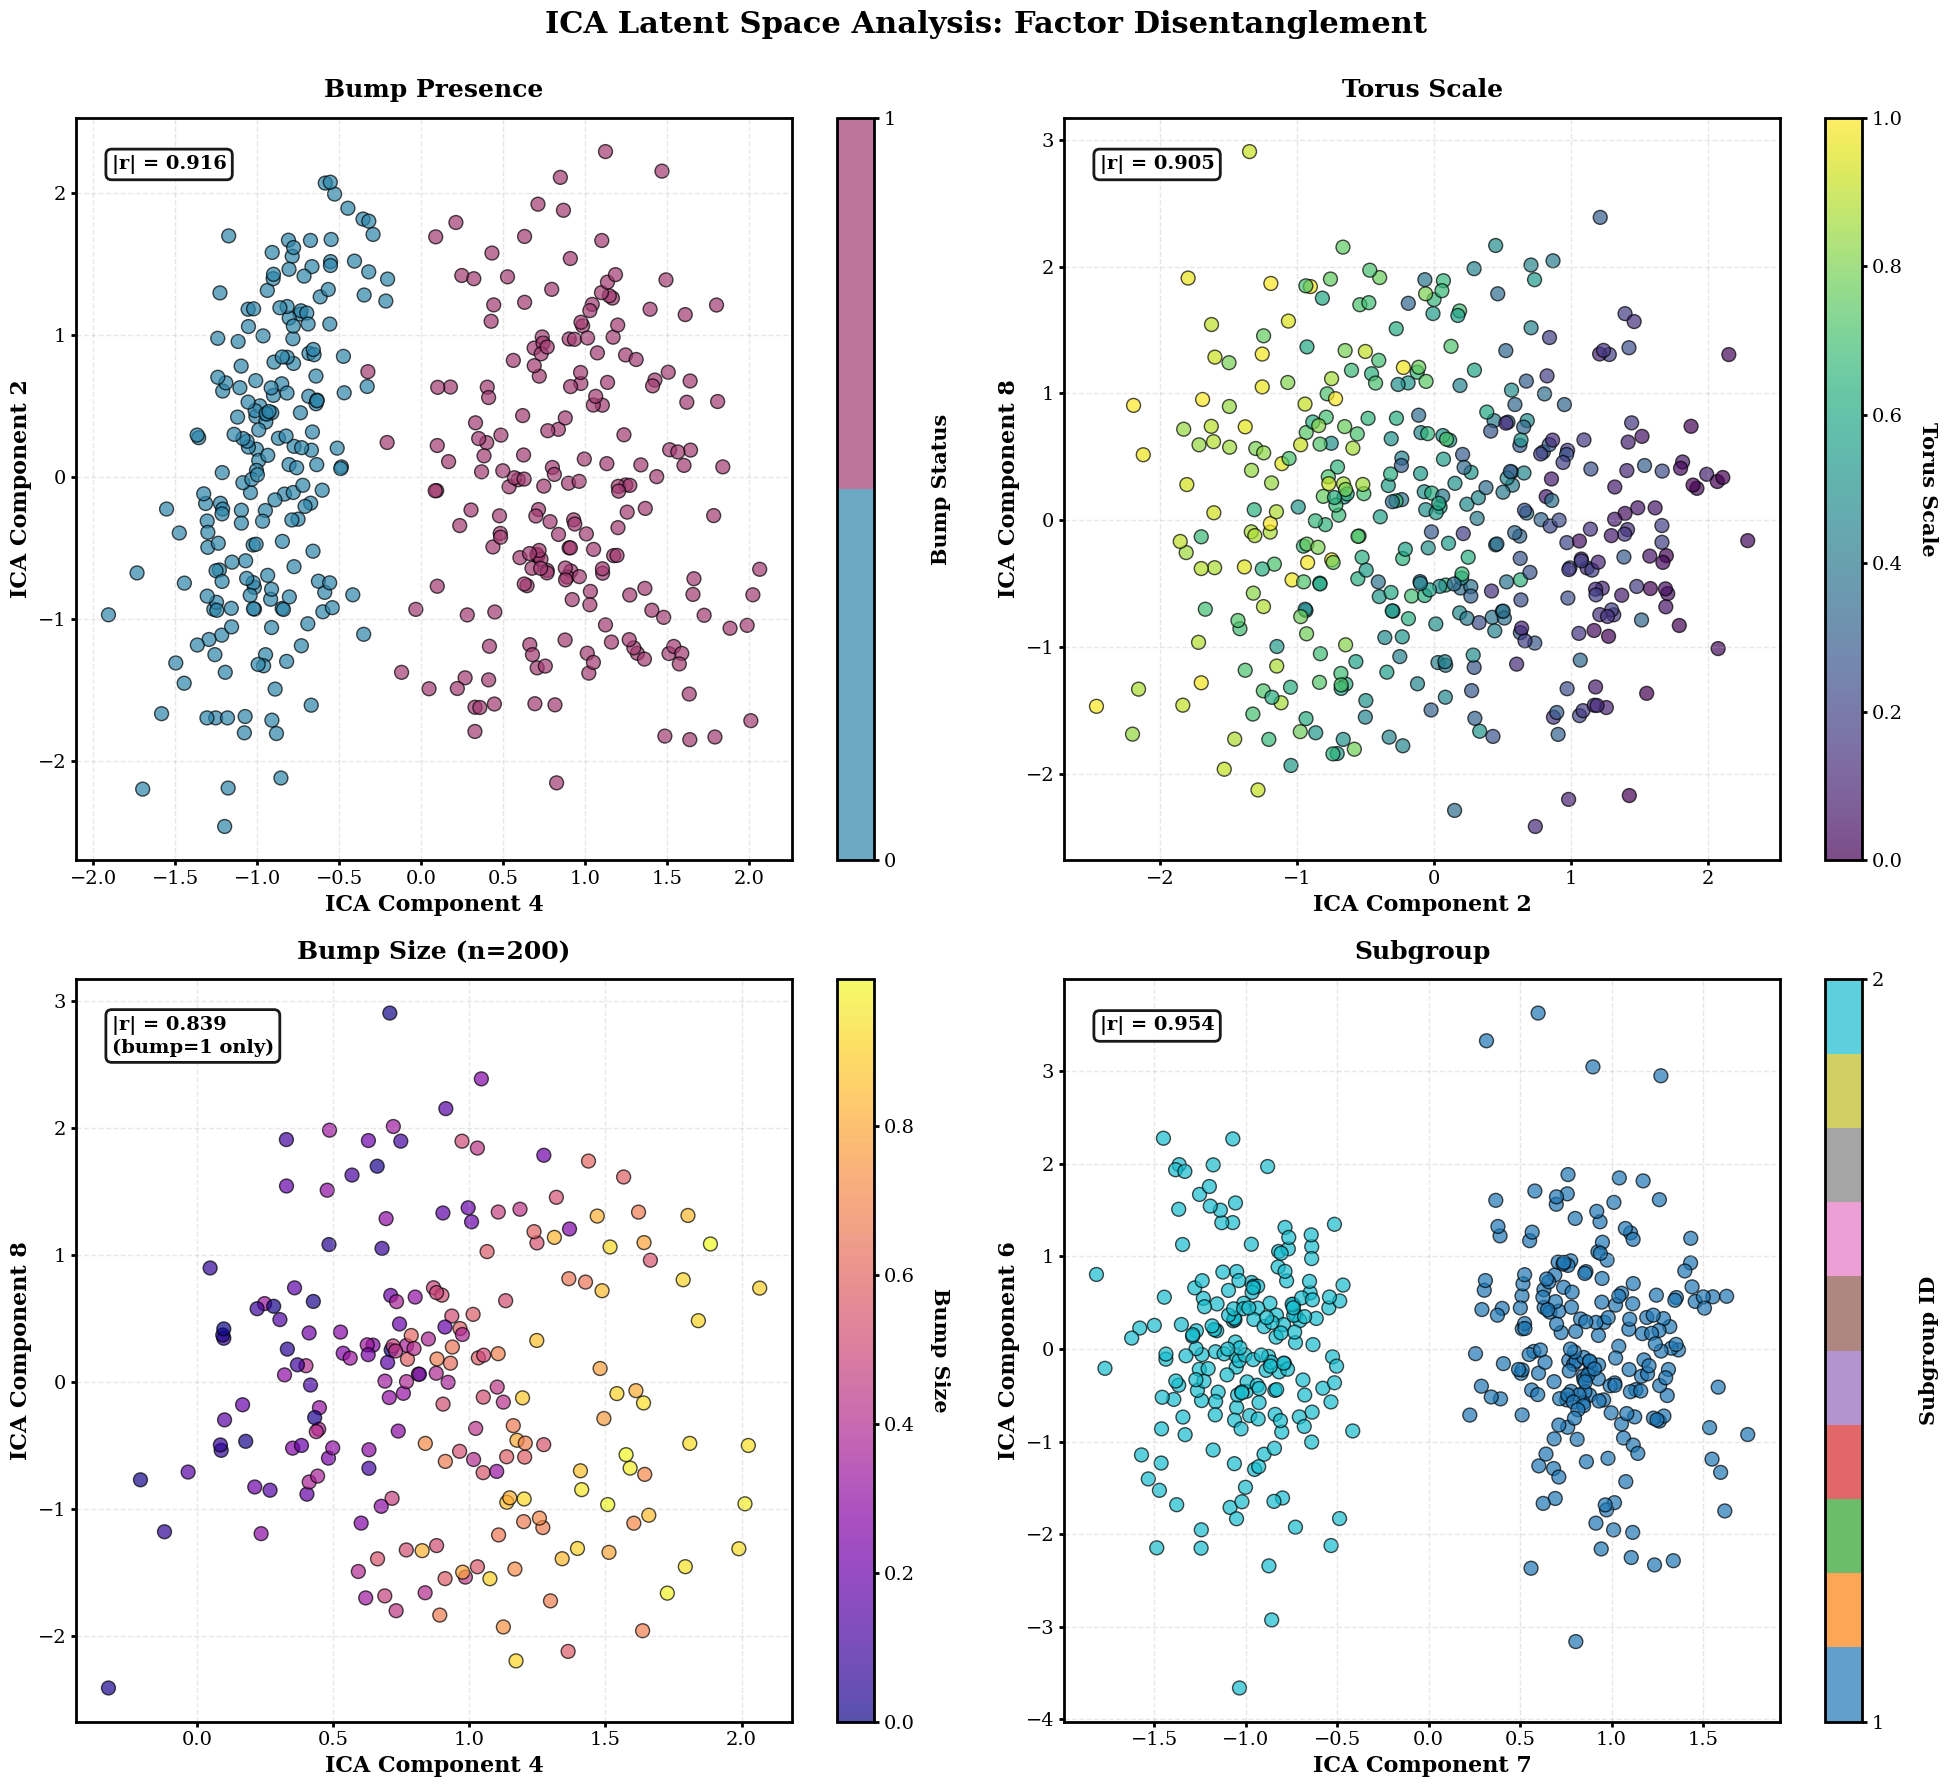


SUMMARY FOR DOCUMENTATION:

Bump Presence:
  Primary Component: ICA Component 4
  Correlation: |r| = 0.9161

Torus Scale:
  Primary Component: ICA Component 2
  Correlation: |r| = 0.9054

Bump Size (bump=1 only):
  Primary Component: ICA Component 4
  Correlation: |r| = 0.8391
  Samples plotted: 200 (only where bump=1)

Subgroup:
  Primary Component: ICA Component 7
  Correlation: |r| = 0.9542


In [39]:
# Professional Publication-Ready Plots for ICA 8 Components
# 2x2 layout with larger text for better visibility

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

# Set publication-quality style with LARGER fonts
plt.rcParams['font.size'] = 16
plt.rcParams['font.family'] = 'serif'
plt.rcParams['axes.linewidth'] = 2.0
plt.rcParams['xtick.major.width'] = 2.0
plt.rcParams['ytick.major.width'] = 2.0
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14

# Define color schemes for each property (professional/standard schemes)
color_schemes = {
    'has_bump': {
        'cmap': ListedColormap(['#2E86AB', '#A23B72']),  # Blue (no bump), Red (bump)
        'label': 'Bump Presence',
        'ticks': [0, 1],
        'tick_labels': ['0', '1']
    },
    'scales': {
        'cmap': 'viridis',  # Standard continuous colormap
        'label': 'Torus Scale',
        'ticks': None,
        'tick_labels': None
    },
    'bump_sizes': {
        'cmap': 'plasma',  # Standard continuous colormap
        'label': 'Bump Size',
        'ticks': None,
        'tick_labels': None
    },
    'subgroups': {
        'cmap': 'tab10',  # Categorical colormap
        'label': 'Subgroup',
        'ticks': None,
        'tick_labels': None
    }
}

# Find best components for each label (from your correlation analysis)
labels_for_plot = {
    'has_bump': has_bump,
    'scales': scales,
    'bump_sizes': bump_sizes,
    'subgroups': subgroups
}

# Calculate best components for each label
best_components = {}
for label_name, label_data in labels_for_plot.items():
    correlations = []
    for comp_idx in range(8):
        if label_name == 'bump_sizes':
            # Only correlate on samples with bumps
            if np.sum(has_bump == 1) > 1:
                corr = np.abs(np.corrcoef(Y_ica_8[has_bump == 1, comp_idx], 
                                         label_data[has_bump == 1])[0, 1])
            else:
                corr = 0
        else:
            corr = np.abs(np.corrcoef(Y_ica_8[:, comp_idx], label_data)[0, 1])
        correlations.append(corr)
    
    best_comp = np.argmax(correlations)
    best_components[label_name] = {
        'component': best_comp,
        'correlation': correlations[best_comp]
    }

print("Best components selected for each property:")
for label, info in best_components.items():
    print(f"  {label}: Component {info['component']+1} (|corr| = {info['correlation']:.4f})")

# Create figure with 2x2 layout
fig, axes = plt.subplots(2, 2, figsize=(20, 18))
fig.suptitle('ICA Latent Space Analysis: Factor Disentanglement', 
             fontsize=22, fontweight='bold', y=0.995)

# Flatten axes for easier iteration
axes = axes.flatten()

# Plot each property
for idx, (label_name, label_data) in enumerate(labels_for_plot.items()):
    ax = axes[idx]
    
    # Get best component for this label
    comp_x = best_components[label_name]['component']
    
    # Find second-best component (different from the best)
    correlations = []
    for comp_idx in range(8):
        if comp_idx == comp_x:
            correlations.append(-1)  # Exclude best component
        else:
            if label_name == 'bump_sizes':
                if np.sum(has_bump == 1) > 1:
                    corr = np.abs(np.corrcoef(Y_ica_8[has_bump == 1, comp_idx], 
                                             label_data[has_bump == 1])[0, 1])
                else:
                    corr = 0
            else:
                corr = np.abs(np.corrcoef(Y_ica_8[:, comp_idx], label_data)[0, 1])
            correlations.append(corr)
    
    comp_y = np.argmax(correlations)
    
    # Get color scheme
    cmap = color_schemes[label_name]['cmap']
    
    # Filter data for bump_sizes: only plot points where has_bump == 1
    if label_name == 'bump_sizes':
        mask = has_bump == 1
        x_data = Y_ica_8[mask, comp_x]
        y_data = Y_ica_8[mask, comp_y]
        color_data = label_data[mask]
        n_samples = np.sum(mask)
    else:
        x_data = Y_ica_8[:, comp_x]
        y_data = Y_ica_8[:, comp_y]
        color_data = label_data
        n_samples = len(label_data)
    
    # Create scatter plot with larger markers
    scatter = ax.scatter(x_data, y_data,
                        c=color_data, cmap=cmap, 
                        s=100, alpha=0.7, edgecolors='black', linewidths=1.0)
    
    # Set labels with larger font
    ax.set_xlabel(f'ICA Component {comp_x+1}', fontsize=16, fontweight='bold')
    ax.set_ylabel(f'ICA Component {comp_y+1}', fontsize=16, fontweight='bold')
    
    # Add sample count for bump_sizes
    if label_name == 'bump_sizes':
        title = f"{color_schemes[label_name]['label']} (n={n_samples})"
    else:
        title = color_schemes[label_name]['label']
    
    ax.set_title(title, fontsize=18, fontweight='bold', pad=15)
    
    # Add grid
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=1.0)
    
    # Add colorbar with larger font
    if label_name == 'has_bump':
        # Discrete colorbar for binary bump
        cbar = plt.colorbar(scatter, ax=ax, ticks=[0, 1])
        cbar.ax.set_yticklabels(['0', '1'], fontsize=14)
        cbar.set_label('Bump Status', rotation=-270, labelpad=25, fontweight='bold', fontsize=15)
    elif label_name == 'subgroups':
        # Discrete colorbar for subgroups
        unique_subgroups = np.unique(subgroups)
        cbar = plt.colorbar(scatter, ax=ax, ticks=unique_subgroups)
        cbar.ax.tick_params(labelsize=14)
        cbar.set_label('Subgroup ID', rotation=-270, labelpad=25, fontweight='bold', fontsize=15)
    else:
        # Continuous colorbar for scales and bump_sizes
        cbar = plt.colorbar(scatter, ax=ax)
        cbar.ax.tick_params(labelsize=14)
        cbar.set_label(color_schemes[label_name]['label'], 
                      rotation=270, labelpad=25, fontweight='bold', fontsize=15)
    
    # Add correlation annotation with larger font
    corr_text = f'|r| = {best_components[label_name]["correlation"]:.3f}'
    if label_name == 'bump_sizes':
        corr_text += f'\n(bump=1 only)'
    
    ax.text(0.05, 0.95, corr_text, transform=ax.transAxes,
           fontsize=14, verticalalignment='top', fontweight='bold',
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, 
                    edgecolor='black', linewidth=2))

plt.tight_layout()
plt.savefig('ICA_factor_analysis_2x2.png', dpi=300, bbox_inches='tight')
plt.savefig('ICA_factor_analysis_2x2.pdf', dpi=300, bbox_inches='tight')
print("\n✅ Plots saved as 'ICA_factor_analysis_2x2.png' and '.pdf'")
plt.show()

# Print summary for documentation
print("\n" + "="*70)
print("SUMMARY FOR DOCUMENTATION:")
print("="*70)
for label_name, info in best_components.items():
    suffix = " (bump=1 only)" if label_name == 'bump_sizes' else ""
    print(f"\n{color_schemes[label_name]['label']}{suffix}:")
    print(f"  Primary Component: ICA Component {info['component']+1}")
    print(f"  Correlation: |r| = {info['correlation']:.4f}")
    if label_name == 'bump_sizes':
        print(f"  Samples plotted: {np.sum(has_bump == 1)} (only where bump=1)")

Best components selected for each property:
  has_bump: Component 4 (|corr| = 0.9161)
  scales: Component 2 (|corr| = 0.9054)
  bump_sizes: Component 4 (|corr| = 0.8391)
  subgroups: Component 7 (|corr| = 0.9542)

✅ Version 1 (1x4) saved as 'ICA_factor_analysis_1x4.png' and '.pdf'


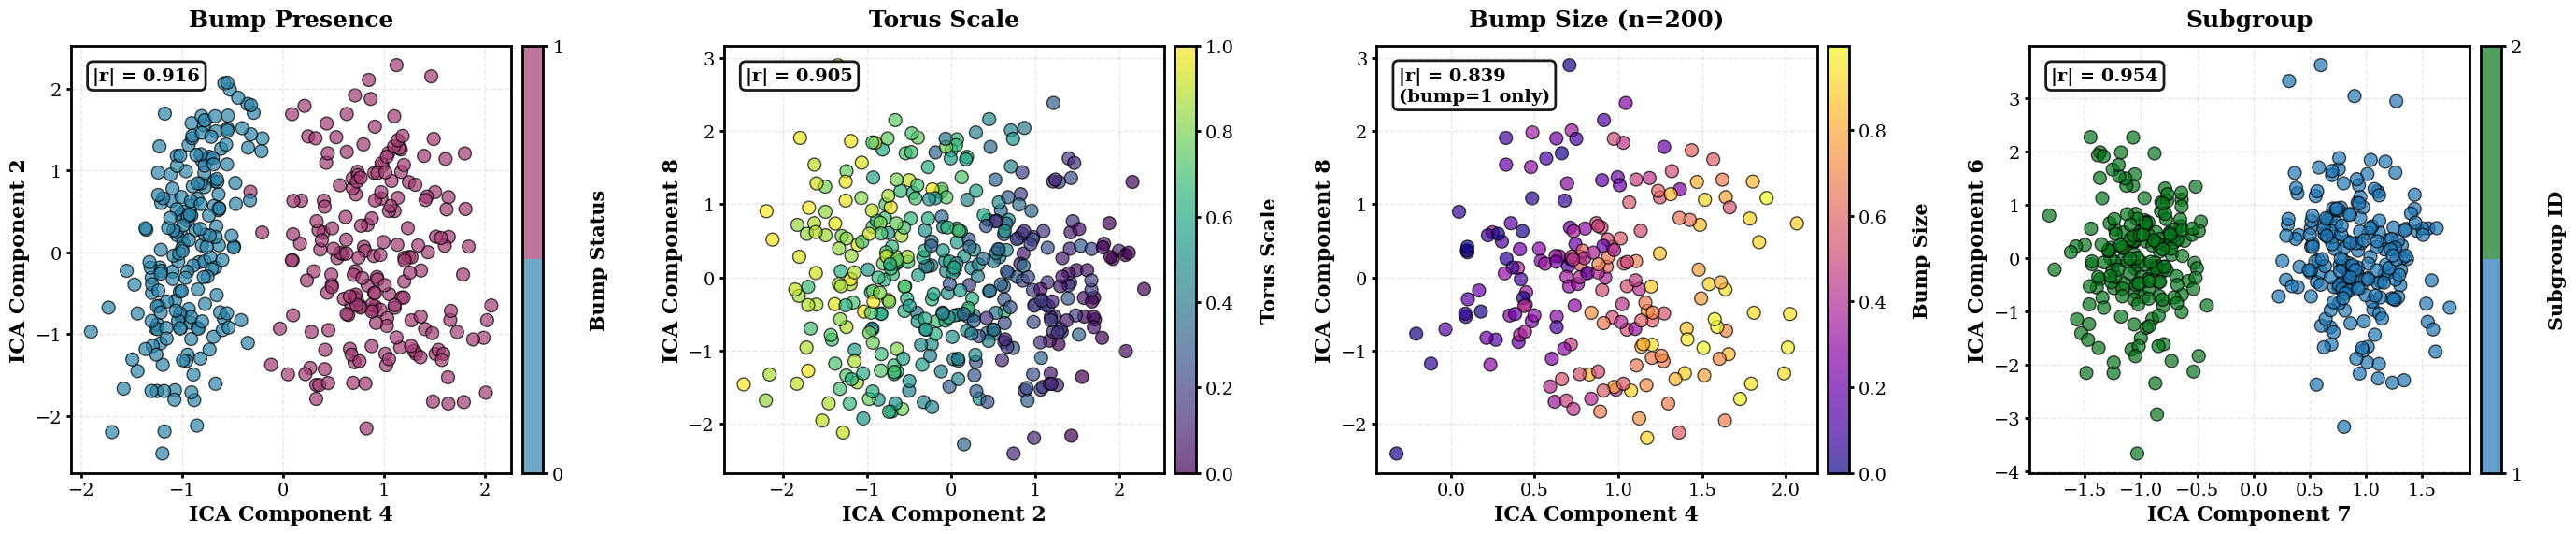

In [46]:
# Professional Publication-Ready Plots for ICA 8 Components
# Version 1: Single row layout (1x4)

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

# Set publication-quality style with LARGER fonts
plt.rcParams['font.size'] = 16
plt.rcParams['font.family'] = 'serif'
plt.rcParams['axes.linewidth'] = 2.0
plt.rcParams['xtick.major.width'] = 2.0
plt.rcParams['ytick.major.width'] = 2.0
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14

# Define color schemes for each property (professional/standard schemes)
color_schemes = {
    'has_bump': {
        'cmap': ListedColormap(['#2E86AB', '#A23B72']),  # Blue (no bump), Red (bump)
        'label': 'Bump Status',  # Changed to match y-axis orientation
        'ticks': [0, 1],
        'tick_labels': ['No Bump', 'Bump']
    },
    'scales': {
        'cmap': 'viridis',
        'label': 'Torus Scale',
        'ticks': None,
        'tick_labels': None
    },
    'bump_sizes': {
        'cmap': 'plasma',
        'label': 'Bump Size',  # Changed to match y-axis orientation
        'ticks': None,
        'tick_labels': None
    },
    'subgroups': {
        'cmap': ListedColormap(['#1f77b4', "#06771C"]),  # Only 2 colors for 2 subgroups
        'label': 'Subgroup ID',
        'ticks': None,
        'tick_labels': None
    }
}

# Find best components for each label
labels_for_plot = {
    'has_bump': has_bump,
    'scales': scales,
    'bump_sizes': bump_sizes,
    'subgroups': subgroups
}

# Calculate best components for each label
best_components = {}
for label_name, label_data in labels_for_plot.items():
    correlations = []
    for comp_idx in range(8):
        if label_name == 'bump_sizes':
            if np.sum(has_bump == 1) > 1:
                corr = np.abs(np.corrcoef(Y_ica_8[has_bump == 1, comp_idx], 
                                         label_data[has_bump == 1])[0, 1])
            else:
                corr = 0
        else:
            corr = np.abs(np.corrcoef(Y_ica_8[:, comp_idx], label_data)[0, 1])
        correlations.append(corr)
    
    best_comp = np.argmax(correlations)
    best_components[label_name] = {
        'component': best_comp,
        'correlation': correlations[best_comp]
    }

print("Best components selected for each property:")
for label, info in best_components.items():
    print(f"  {label}: Component {info['component']+1} (|corr| = {info['correlation']:.4f})")

# VERSION 1: Single row layout (1x4)
fig, axes = plt.subplots(1, 4, figsize=(28, 6))
#fig.suptitle('ICA Latent Space Analysis: Factor Disentanglement', 
             #fontsize=22, fontweight='bold', y=1.02)

# Plot each property
for idx, (label_name, label_data) in enumerate(labels_for_plot.items()):
    ax = axes[idx]
    
    # Get best component for this label
    comp_x = best_components[label_name]['component']
    
    # Find second-best component
    correlations = []
    for comp_idx in range(8):
        if comp_idx == comp_x:
            correlations.append(-1)
        else:
            if label_name == 'bump_sizes':
                if np.sum(has_bump == 1) > 1:
                    corr = np.abs(np.corrcoef(Y_ica_8[has_bump == 1, comp_idx], 
                                             label_data[has_bump == 1])[0, 1])
                else:
                    corr = 0
            else:
                corr = np.abs(np.corrcoef(Y_ica_8[:, comp_idx], label_data)[0, 1])
            correlations.append(corr)
    
    comp_y = np.argmax(correlations)
    
    # Get color scheme
    cmap = color_schemes[label_name]['cmap']
    
    # Filter data for bump_sizes: only plot points where has_bump == 1
    if label_name == 'bump_sizes':
        mask = has_bump == 1
        x_data = Y_ica_8[mask, comp_x]
        y_data = Y_ica_8[mask, comp_y]
        color_data = label_data[mask]
        n_samples = np.sum(mask)
    else:
        x_data = Y_ica_8[:, comp_x]
        y_data = Y_ica_8[:, comp_y]
        color_data = label_data
        n_samples = len(label_data)
    
    # Create scatter plot
    scatter = ax.scatter(x_data, y_data,
                        c=color_data, cmap=cmap, 
                        s=100, alpha=0.7, edgecolors='black', linewidths=1.0)
    
    # Set labels
    ax.set_xlabel(f'ICA Component {comp_x+1}', fontsize=16, fontweight='bold')
    ax.set_ylabel(f'ICA Component {comp_y+1}', fontsize=16, fontweight='bold')
    
    # Add sample count for bump_sizes
    if label_name == 'bump_sizes':
        title = f"Bump Size (n={n_samples})"
    elif label_name == 'has_bump':
        title = "Bump Presence"
    elif label_name == 'scales':
        title = "Torus Scale"
    else:
        title = "Subgroup"
    
    ax.set_title(title, fontsize=18, fontweight='bold', pad=15)
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=1.0)
    
    # Add colorbar with proper settings
    if label_name == 'has_bump':
        cbar = plt.colorbar(scatter, ax=ax, ticks=[0, 1], pad=0.02)
        cbar.ax.set_yticklabels(['0', '1'], fontsize=14)
        cbar.set_label(color_schemes[label_name]['label'], 
                      rotation=-270, labelpad=20, fontweight='bold', fontsize=15)
    elif label_name == 'subgroups':
        unique_subgroups = np.unique(subgroups)
        cbar = plt.colorbar(scatter, ax=ax, ticks=unique_subgroups, pad=0.02)
        cbar.ax.tick_params(labelsize=14)
        cbar.set_label(color_schemes[label_name]['label'], 
                      rotation=-270, labelpad=20, fontweight='bold', fontsize=15)
    else:
        cbar = plt.colorbar(scatter, ax=ax, pad=0.02)
        cbar.ax.tick_params(labelsize=14)
        cbar.set_label(color_schemes[label_name]['label'], 
                      rotation=-270, labelpad=20, fontweight='bold', fontsize=15)
    
    # Add correlation annotation
    corr_text = f'|r| = {best_components[label_name]["correlation"]:.3f}'
    if label_name == 'bump_sizes':
        corr_text += f'\n(bump=1 only)'
    
    ax.text(0.05, 0.95, corr_text, transform=ax.transAxes,
           fontsize=14, verticalalignment='top', fontweight='bold',
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, 
                    edgecolor='black', linewidth=2))

plt.tight_layout()
plt.savefig('ICA_factor_analysis_1x4.png', dpi=300, bbox_inches='tight')
plt.savefig('ICA_factor_analysis_1x4.pdf', dpi=300, bbox_inches='tight')
print("\n✅ Version 1 (1x4) saved as 'ICA_factor_analysis_1x4.png' and '.pdf'")
plt.show()


✅ Version 2 (2x2) saved as 'ICA_factor_analysis_2x2.png' and '.pdf'


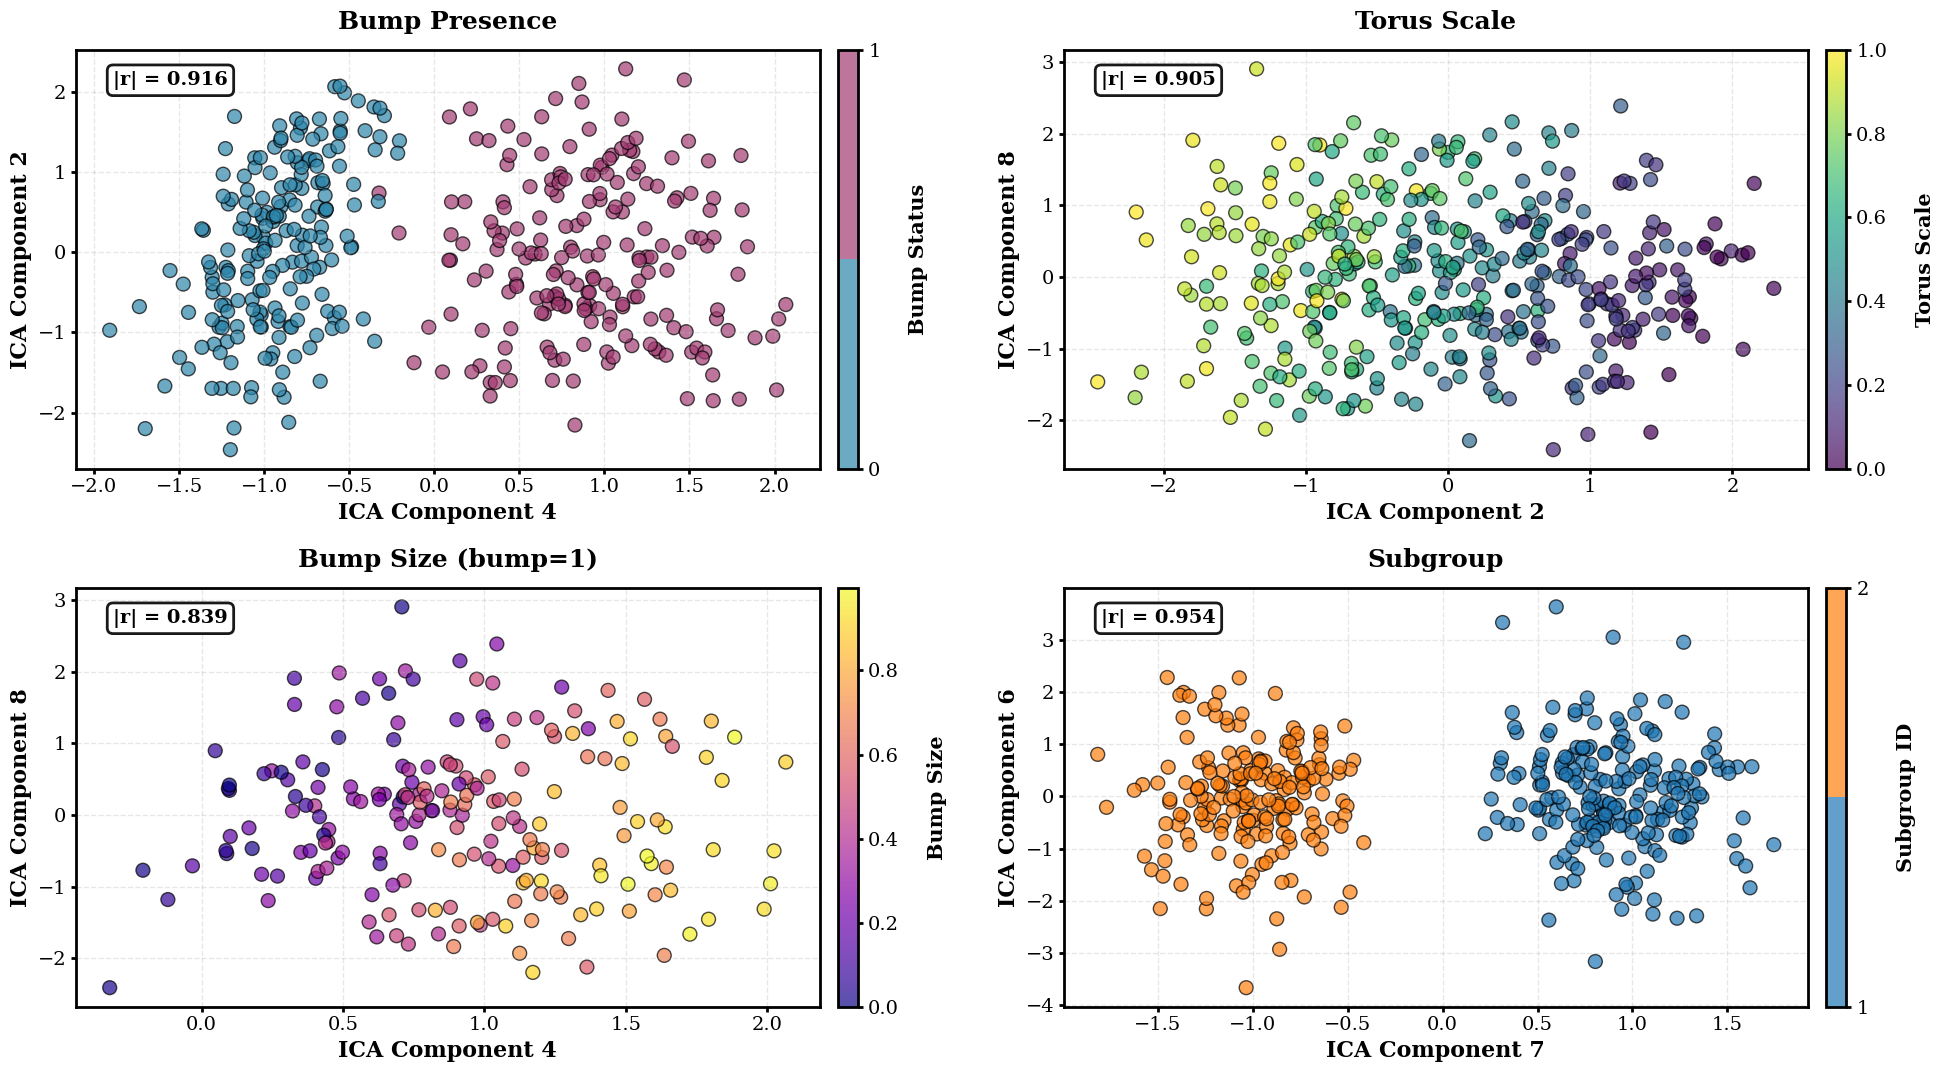


SUMMARY FOR DOCUMENTATION:

Bump Status:
  Primary Component: ICA Component 4
  Correlation: |r| = 0.9161

Torus Scale:
  Primary Component: ICA Component 2
  Correlation: |r| = 0.9054

Bump Size (bump=1 only):
  Primary Component: ICA Component 4
  Correlation: |r| = 0.8391
  Samples plotted: 200 (only where bump=1)

Subgroup ID:
  Primary Component: ICA Component 7
  Correlation: |r| = 0.9542


In [47]:
# Professional Publication-Ready Plots for ICA 8 Components
# Version 2: Two rows with reduced height (2x2)

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Set publication-quality style with LARGER fonts
plt.rcParams['font.size'] = 16
plt.rcParams['font.family'] = 'serif'
plt.rcParams['axes.linewidth'] = 2.0
plt.rcParams['xtick.major.width'] = 2.0
plt.rcParams['ytick.major.width'] = 2.0
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14

# Define color schemes (same as Version 1)
color_schemes = {
    'has_bump': {
        'cmap': ListedColormap(['#2E86AB', '#A23B72']),
        'label': 'Bump Status',  # Changed to match orientation
        'ticks': [0, 1],
        'tick_labels': ['No Bump', 'Bump']
    },
    'scales': {
        'cmap': 'viridis',
        'label': 'Torus Scale',
        'ticks': None,
        'tick_labels': None
    },
    'bump_sizes': {
        'cmap': 'plasma',
        'label': 'Bump Size',  # Changed to match orientation
        'ticks': None,
        'tick_labels': None
    },
    'subgroups': {
        'cmap': ListedColormap(['#1f77b4', '#ff7f0e']),  # Only 2 colors
        'label': 'Subgroup ID',
        'ticks': None,
        'tick_labels': None
    }
}

# VERSION 2: Two rows with reduced height (2x2)
fig, axes = plt.subplots(2, 2, figsize=(20, 11))  # Reduced height from 18 to 11
#fig.suptitle('ICA Latent Space Analysis: Factor Disentanglement', 
             #fontsize=22, fontweight='bold', y=0.995)

# Flatten axes
axes = axes.flatten()

# Plot each property
for idx, (label_name, label_data) in enumerate(labels_for_plot.items()):
    ax = axes[idx]
    
    # Get best component for this label
    comp_x = best_components[label_name]['component']
    
    # Find second-best component
    correlations = []
    for comp_idx in range(8):
        if comp_idx == comp_x:
            correlations.append(-1)
        else:
            if label_name == 'bump_sizes':
                if np.sum(has_bump == 1) > 1:
                    corr = np.abs(np.corrcoef(Y_ica_8[has_bump == 1, comp_idx], 
                                             label_data[has_bump == 1])[0, 1])
                else:
                    corr = 0
            else:
                corr = np.abs(np.corrcoef(Y_ica_8[:, comp_idx], label_data)[0, 1])
            correlations.append(corr)
    
    comp_y = np.argmax(correlations)
    
    # Get color scheme
    cmap = color_schemes[label_name]['cmap']
    
    # Filter data for bump_sizes
    if label_name == 'bump_sizes':
        mask = has_bump == 1
        x_data = Y_ica_8[mask, comp_x]
        y_data = Y_ica_8[mask, comp_y]
        color_data = label_data[mask]
        n_samples = np.sum(mask)
    else:
        x_data = Y_ica_8[:, comp_x]
        y_data = Y_ica_8[:, comp_y]
        color_data = label_data
        n_samples = len(label_data)
    
    # Create scatter plot
    scatter = ax.scatter(x_data, y_data,
                        c=color_data, cmap=cmap, 
                        s=100, alpha=0.7, edgecolors='black', linewidths=1.0)
    
    # Set labels
    ax.set_xlabel(f'ICA Component {comp_x+1}', fontsize=16, fontweight='bold')
    ax.set_ylabel(f'ICA Component {comp_y+1}', fontsize=16, fontweight='bold')
    
    # Titles
    if label_name == 'bump_sizes':
        title = f"Bump Size (bump=1)"
    elif label_name == 'has_bump':
        title = "Bump Presence"
    elif label_name == 'scales':
        title = "Torus Scale"
    else:
        title = "Subgroup"
    
    ax.set_title(title, fontsize=18, fontweight='bold', pad=15)
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=1.0)
    
    # Add colorbar with reduced padding
    if label_name == 'has_bump':
        cbar = plt.colorbar(scatter, ax=ax, ticks=[0, 1], pad=0.02)
        cbar.ax.set_yticklabels(['0', '1'], fontsize=14)
        cbar.set_label(color_schemes[label_name]['label'], 
                      rotation=-270, labelpad=20, fontweight='bold', fontsize=15)
    elif label_name == 'subgroups':
        unique_subgroups = np.unique(subgroups)
        cbar = plt.colorbar(scatter, ax=ax, ticks=unique_subgroups, pad=0.02)
        cbar.ax.tick_params(labelsize=14)
        cbar.set_label(color_schemes[label_name]['label'], 
                      rotation=-270, labelpad=20, fontweight='bold', fontsize=15)
    else:
        cbar = plt.colorbar(scatter, ax=ax, pad=0.02)
        cbar.ax.tick_params(labelsize=14)
        cbar.set_label(color_schemes[label_name]['label'], 
                      rotation=-270, labelpad=20, fontweight='bold', fontsize=15)
    
    # Add correlation annotation
    corr_text = f'|r| = {best_components[label_name]["correlation"]:.3f}'
    #if label_name == 'bump_sizes':
        #corr_text += f'\n(bump=1 only)'
    
    ax.text(0.05, 0.95, corr_text, transform=ax.transAxes,
           fontsize=14, verticalalignment='top', fontweight='bold',
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, 
                    edgecolor='black', linewidth=2))

plt.tight_layout()
plt.savefig('ICA_factor_analysis_2x2.png', dpi=300, bbox_inches='tight')
plt.savefig('ICA_factor_analysis_2x2.pdf', dpi=300, bbox_inches='tight')
print("\n✅ Version 2 (2x2) saved as 'ICA_factor_analysis_2x2.png' and '.pdf'")
plt.show()

# Print summary
print("\n" + "="*70)
print("SUMMARY FOR DOCUMENTATION:")
print("="*70)
for label_name, info in best_components.items():
    suffix = " (bump=1 only)" if label_name == 'bump_sizes' else ""
    print(f"\n{color_schemes[label_name]['label']}{suffix}:")
    print(f"  Primary Component: ICA Component {info['component']+1}")
    print(f"  Correlation: |r| = {info['correlation']:.4f}")
    if label_name == 'bump_sizes':
        print(f"  Samples plotted: {np.sum(has_bump == 1)} (only where bump=1)")

In [25]:
# PCA with 8 components - correlation analysis with all labels

import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA with exactly 8 components
print("Applying PCA with 8 components...")
pca_8 = PCA(n_components=8)
Y_pca_8 = pca_8.fit_transform(X_scaled)

print(f"PCA 8-component shape: {Y_pca_8.shape}")
print(f"PCA explained variance ratio: {pca_8.explained_variance_ratio_.sum():.4f}")
print("\n" + "="*70)
print("PCA 8-COMPONENT CORRELATION ANALYSIS WITH ALL LABELS")
print("="*70)

# Create mask for samples with bumps
samples_with_bump = has_bump == 1
n_bump_samples = np.sum(samples_with_bump)
print(f"\nTotal samples: {len(has_bump)}")
print(f"Samples with bumps: {n_bump_samples}")
print(f"Samples without bumps: {len(has_bump) - n_bump_samples}")

# Define labels for correlation
labels_dict_pca = {
    'has_bump': has_bump,
    'scales': scales,
    'bump_sizes': bump_sizes,
    'subgroups': subgroups
}

# Correlation matrix: rows = components, columns = labels
correlation_matrix_pca = np.zeros((8, len(labels_dict_pca)))
label_names_pca = list(labels_dict_pca.keys())

# Calculate correlations for each component with each label
for comp_idx in range(8):
    print(f"\nComponent {comp_idx+1} (Explained variance: {pca_8.explained_variance_ratio_[comp_idx]:.4f}):")
    for label_idx, (label_name, label_data) in enumerate(labels_dict_pca.items()):
        # Special handling: ONLY bump_sizes is conditional on bump=1
        if label_name == 'bump_sizes':
            if n_bump_samples > 1:
                corr = np.corrcoef(Y_pca_8[samples_with_bump, comp_idx], 
                                  label_data[samples_with_bump])[0, 1]
                correlation_matrix_pca[comp_idx, label_idx] = corr
                print(f"  Correlation with {label_name:12s} (bump=1 only, n={n_bump_samples}): {corr:+.4f}")
            else:
                correlation_matrix_pca[comp_idx, label_idx] = 0.0
                print(f"  Correlation with {label_name:12s}: N/A (insufficient samples)")
        else:
            # Regular correlation for has_bump, scales, and subgroups (use ALL samples)
            corr = np.corrcoef(Y_pca_8[:, comp_idx], label_data)[0, 1]
            correlation_matrix_pca[comp_idx, label_idx] = corr
            print(f"  Correlation with {label_name:12s}: {corr:+.4f}")

# Find best component for each label
print("\n" + "="*70)
print("BEST COMPONENT FOR EACH LABEL:")
print("="*70)
for label_idx, label_name in enumerate(label_names_pca):
    abs_corrs = np.abs(correlation_matrix_pca[:, label_idx])
    best_comp = np.argmax(abs_corrs)
    best_corr = correlation_matrix_pca[best_comp, label_idx]
    
    if label_name == 'bump_sizes':
        print(f"{label_name:12s}: Component {best_comp+1} (corr = {best_corr:+.4f}, |corr| = {abs_corrs[best_comp]:.4f}) [bump=1 only]")
    else:
        print(f"{label_name:12s}: Component {best_comp+1} (corr = {best_corr:+.4f}, |corr| = {abs_corrs[best_comp]:.4f})")

# Check if scale is encoded as distance from origin
print("\n" + "="*70)
print("DISTANCE FROM ORIGIN ANALYSIS:")
print("="*70)
center = np.mean(Y_pca_8, axis=0)
distances = np.sqrt(np.sum((Y_pca_8 - center) ** 2, axis=1))
dist_corr_all = np.corrcoef(distances, scales)[0, 1]
print(f"Correlation between distance from origin and scale (ALL samples): {dist_corr_all:+.4f}")

if n_bump_samples > 1:
    dist_corr_bump = np.corrcoef(distances[samples_with_bump], scales[samples_with_bump])[0, 1]
    print(f"Correlation between distance from origin and scale (bump=1 only): {dist_corr_bump:+.4f}")

# Store results
results["PCA_8"] = Y_pca_8
transformed_latents["PCA_8"] = Y_pca_8

print("\n✅ PCA with 8 components completed!")
print(f"✅ Results stored in results['PCA_8'] and transformed_latents['PCA_8']")
print(f"✅ Correlation analysis completed!")
print(f"   - has_bump, scales & subgroups: ALL samples")
print(f"   - bump_sizes: ONLY bump=1 samples")

Applying PCA with 8 components...
PCA 8-component shape: (400, 8)
PCA explained variance ratio: 0.9308

PCA 8-COMPONENT CORRELATION ANALYSIS WITH ALL LABELS

Total samples: 400
Samples with bumps: 200
Samples without bumps: 200

Component 1 (Explained variance: 0.3696):
  Correlation with has_bump    : +0.8708
  Correlation with scales      : +0.1619
  Correlation with bump_sizes   (bump=1 only, n=200): +0.7914
  Correlation with subgroups   : -0.0983

Component 2 (Explained variance: 0.2107):
  Correlation with has_bump    : -0.1076
  Correlation with scales      : -0.1784
  Correlation with bump_sizes   (bump=1 only, n=200): -0.1833
  Correlation with subgroups   : -0.9295

Component 3 (Explained variance: 0.1118):
  Correlation with has_bump    : -0.0235
  Correlation with scales      : +0.8613
  Correlation with bump_sizes   (bump=1 only, n=200): -0.1145
  Correlation with subgroups   : -0.1555

Component 4 (Explained variance: 0.0894):
  Correlation with has_bump    : -0.1099
  Co

Data shape: (400, 16)

📊 Step 1: Intrinsic Dimension Estimation
Dimensions needed:
  90% variance: 7D
  95% variance: 9D
  99% variance: 13D


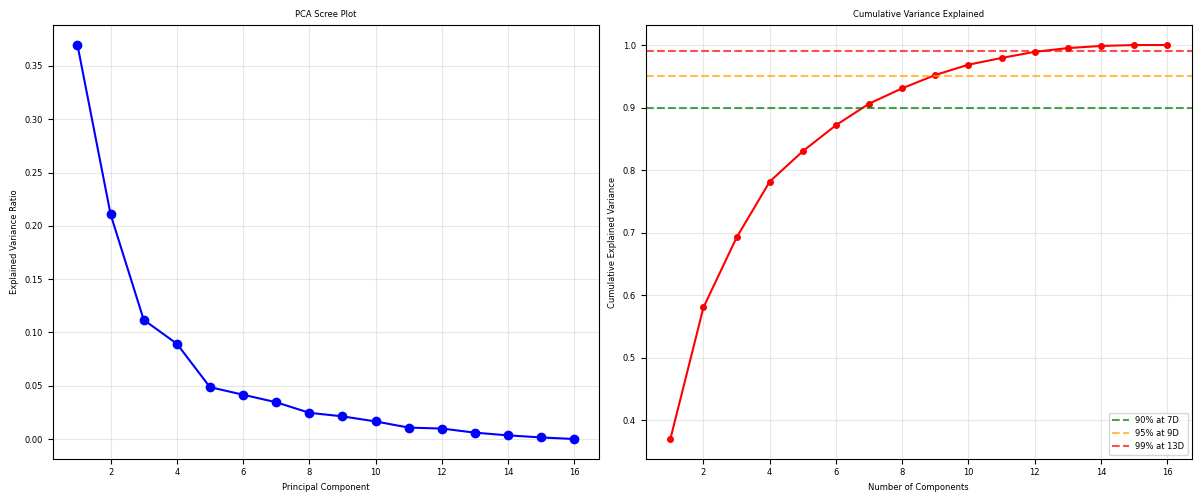


🎯 Step 2: HLLE Dimension Selection (TRUSTWORTHINESS ONLY)
Using k_neighbors = 50
   Testing d_geo = 3...
     Trustworthiness: 0.9478
   Testing d_geo = 4...
     Trustworthiness: 0.9682
   Testing d_geo = 5...
     Trustworthiness: 0.9766
   Testing d_geo = 6...
     Trustworthiness: 0.9803
   Testing d_geo = 8...
     Trustworthiness: 0.9770
   Testing d_geo = 9...
     Failed: for method='hessian', n_neighbors must be greater than [n_components * (n_components + 3) / 2]

🏆 Best HLLE dimension: 6D (trustworthiness: 0.9803)

🔬 Step 3: ICA with FIXED 6 COMPONENTS & COMPREHENSIVE METRICS
🔹 Using FIXED 6 ICA components

📈 COMPREHENSIVE ICA COMPONENT ANALYSIS

📊 DETAILED METRICS FOR ALL 6 ICA COMPONENTS:
--------------------------------------------------------------------------------

Component 1:
  Kurtosis:          -1.5464
  Skewness:          -0.0764
  Negentropy (tanh): 0.0025
  Negentropy (exp):  0.0000
  Entropy:           -771.2338
  Variance:          0.0025
  Range:            

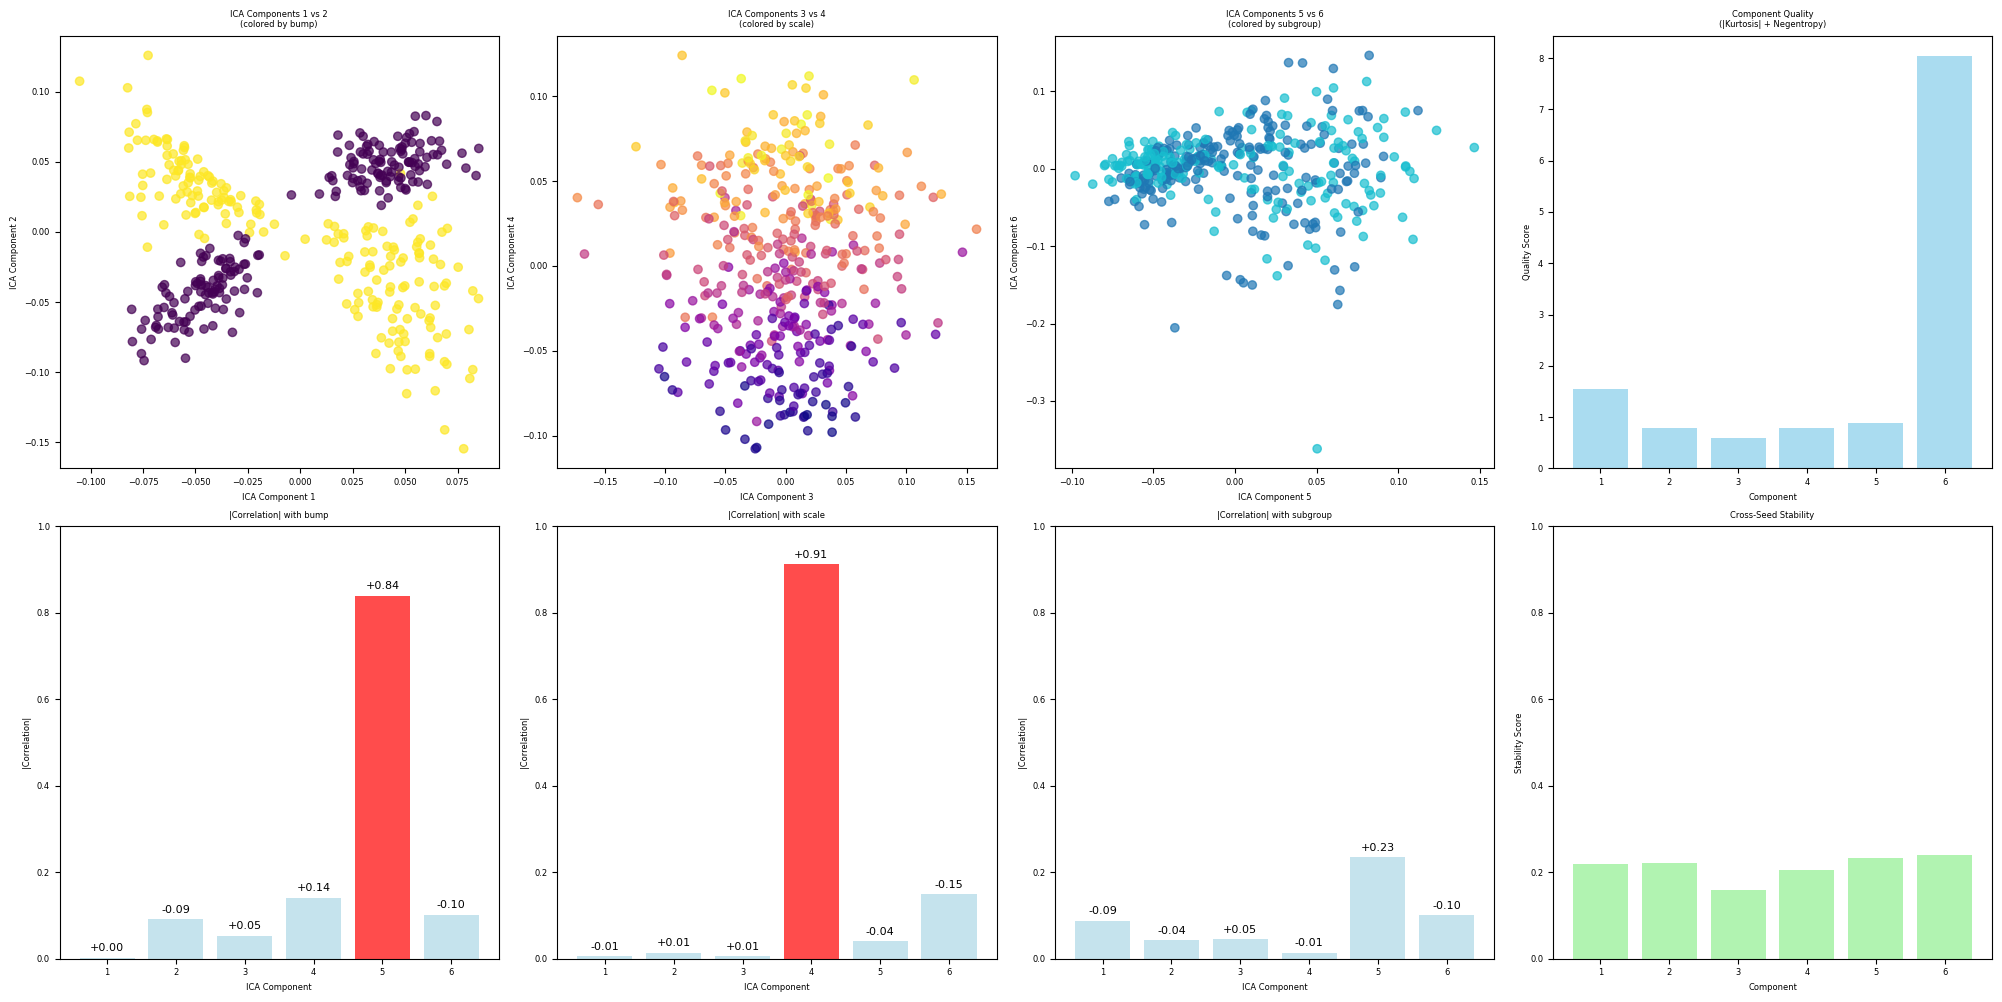

✅ Model-free pipeline complete with FIXED 6 ICA components!
✅ Comprehensive component metrics calculated!
✅ Cross-seed stability analysis completed!
✅ Factor correlation analysis finished!


In [16]:
# =============================================================
# Evidence-Based HLLE + ICA with FIXED 6 COMPONENTS & COMPREHENSIVE METRICS
# =============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import LocallyLinearEmbedding, trustworthiness
from sklearn.decomposition import PCA, FastICA
from sklearn.preprocessing import StandardScaler
from scipy.stats import kurtosis, skew, entropy
import warnings
warnings.filterwarnings('ignore')

# Your data
print(f"Data shape: {X.shape}")  # (400, 16)

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\n📊 Step 1: Intrinsic Dimension Estimation")
print("==========================================")

# PCA scree plot analysis
pca = PCA()
pca.fit(X_scaled)
explained_var_ratio = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var_ratio)

# Find dimensions for different variance thresholds
dim_90 = np.argmax(cumulative_var >= 0.90) + 1
dim_95 = np.argmax(cumulative_var >= 0.95) + 1
dim_99 = np.argmax(cumulative_var >= 0.99) + 1

print(f"Dimensions needed:")
print(f"  90% variance: {dim_90}D")
print(f"  95% variance: {dim_95}D")
print(f"  99% variance: {dim_99}D")

# Plot PCA analysis
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Scree plot
axes[0].plot(range(1, 17), explained_var_ratio, 'bo-', markersize=6)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('PCA Scree Plot')
axes[0].grid(True, alpha=0.3)

# Cumulative variance
axes[1].plot(range(1, 17), cumulative_var, 'ro-', markersize=4)
axes[1].axhline(y=0.90, color='green', linestyle='--', alpha=0.7, label=f'90% at {dim_90}D')
axes[1].axhline(y=0.95, color='orange', linestyle='--', alpha=0.7, label=f'95% at {dim_95}D')
axes[1].axhline(y=0.99, color='red', linestyle='--', alpha=0.7, label=f'99% at {dim_99}D')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Cumulative Variance Explained')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n🎯 Step 2: HLLE Dimension Selection (TRUSTWORTHINESS ONLY)")
print("========================================================")

# Test HLLE dimensions - conservative approach for small dataset
d_geo_candidates = [3, 4, 5, 6, 8, min(10, dim_95)]
k_neighbors = min(50, X.shape[0] // 8)  # Conservative: ~50 neighbors for 400 samples

print(f"Using k_neighbors = {k_neighbors}")

hlle_results = {}
trustworthiness_scores = {}

for d_geo in d_geo_candidates:
    try:
        print(f"   Testing d_geo = {d_geo}...")
        
        # Fit HLLE
        hlle = LocallyLinearEmbedding(
            n_neighbors=k_neighbors,
            n_components=d_geo,
            method='hessian',
            random_state=42,
            eigen_solver='dense'  # More stable for small datasets
        )
        Y_hlle = hlle.fit_transform(X_scaled)
        
        # Compute ONLY trustworthiness - NO reconstruction error
        trust_score = trustworthiness(X_scaled, Y_hlle, n_neighbors=min(k_neighbors, 30))
        
        hlle_results[d_geo] = Y_hlle
        trustworthiness_scores[d_geo] = trust_score
        
        print(f"     Trustworthiness: {trust_score:.4f}")
        
    except Exception as e:
        print(f"     Failed: {str(e)}")
        continue

# Select best HLLE dimension based ONLY on trustworthiness
if trustworthiness_scores:
    best_d_geo = max(trustworthiness_scores, key=trustworthiness_scores.get)
    best_trust = trustworthiness_scores[best_d_geo]
    print(f"\n🏆 Best HLLE dimension: {best_d_geo}D (trustworthiness: {best_trust:.4f})")
else:
    # Fallback based on PCA
    best_d_geo = min(8, dim_95)
    print(f"\n⚠️  HLLE failed, using PCA-based fallback: {best_d_geo}D")
    pca_fallback = PCA(n_components=best_d_geo)
    hlle_results[best_d_geo] = pca_fallback.fit_transform(X_scaled)

print("\n🔬 Step 3: ICA with FIXED 6 COMPONENTS & COMPREHENSIVE METRICS") 
print("==============================================================")

Y_hlle_best = hlle_results[best_d_geo]

# FIXED: Use exactly 6 ICA components
n_ica_components = 6
print(f"🔹 Using FIXED {n_ica_components} ICA components")

# Multiple random seeds for stability assessment
print(f"\n📈 COMPREHENSIVE ICA COMPONENT ANALYSIS")
print("=" * 50)

ica_embeddings = []
all_seeds = [42, 123, 456, 789, 999]

for seed in all_seeds:
    ica = FastICA(
        n_components=n_ica_components,
        whiten='arbitrary-variance',
        random_state=seed,
        max_iter=2000,
        tol=1e-6
    )
    S_ica = ica.fit_transform(Y_hlle_best)
    ica_embeddings.append(S_ica)

# Use first seed as main result
S_final = ica_embeddings[0]

# Comprehensive component quality metrics
def calculate_negentropy_tanh(x):
    """Negentropy approximation using tanh"""
    return np.mean(np.tanh(x)**2) - (np.mean(np.tanh(x)))**2

def calculate_negentropy_exp(x):
    """Negentropy approximation using exp"""
    return np.mean(x * np.exp(-x**2/2)) - (np.mean(x * np.exp(-x**2/2)))**2

def calculate_entropy(x, bins=50):
    """Discrete entropy estimate"""
    hist, _ = np.histogram(x, bins=bins, density=True)
    hist = hist[hist > 0]  # Remove zeros
    return -np.sum(hist * np.log2(hist + 1e-10))

print(f"\n📊 DETAILED METRICS FOR ALL {n_ica_components} ICA COMPONENTS:")
print("-" * 80)

component_metrics = {}
for i in range(n_ica_components):
    comp = S_final[:, i]
    
    # Calculate all metrics
    kurt_val = kurtosis(comp)
    skew_val = skew(comp)
    negent_tanh = calculate_negentropy_tanh(comp)
    negent_exp = calculate_negentropy_exp(comp)
    entropy_val = calculate_entropy(comp)
    variance_val = np.var(comp)
    range_val = np.max(comp) - np.min(comp)
    
    component_metrics[f'component_{i+1}'] = {
        'kurtosis': kurt_val,
        'skewness': skew_val,
        'negentropy_tanh': negent_tanh,
        'negentropy_exp': negent_exp,
        'entropy': entropy_val,
        'variance': variance_val,
        'range': range_val
    }
    
    print(f"\nComponent {i+1}:")
    print(f"  Kurtosis:          {kurt_val:.4f}")
    print(f"  Skewness:          {skew_val:.4f}")
    print(f"  Negentropy (tanh): {negent_tanh:.4f}")
    print(f"  Negentropy (exp):  {negent_exp:.4f}")
    print(f"  Entropy:           {entropy_val:.4f}")
    print(f"  Variance:          {variance_val:.4f}")
    print(f"  Range:             {range_val:.4f}")

print(f"\n🎯 STABILITY ANALYSIS ACROSS SEEDS")
print("=" * 40)

# Cross-seed stability analysis
stability_scores_per_comp = []
for comp_idx in range(n_ica_components):
    correlations = []
    for i in range(len(ica_embeddings)-1):
        for j in range(i+1, len(ica_embeddings)):
            # Compute correlation between same components across seeds
            corr = np.abs(np.corrcoef(ica_embeddings[i][:, comp_idx], 
                                    ica_embeddings[j][:, comp_idx])[0, 1])
            correlations.append(corr)
    
    comp_stability = np.mean(correlations)
    stability_scores_per_comp.append(comp_stability)
    print(f"Component {comp_idx+1} stability: {comp_stability:.4f}")

overall_stability = np.mean(stability_scores_per_comp)
print(f"\nOverall stability across seeds: {overall_stability:.4f}")

print(f"\n🔗 FACTOR CORRELATION ANALYSIS")
print("=" * 35)

# Factor correlation analysis
factor_correlations = {}
factor_names_local = ['has_bump', 'scales', 'bump_sizes', 'subgroups']
factor_data = [has_bump, scales, bump_sizes, subgroups]

correlation_matrix = np.zeros((len(factor_names_local), n_ica_components))

for f_idx, (f_name, f_data) in enumerate(zip(factor_names_local, factor_data)):
    print(f"\n{f_name.upper()} correlations:")
    factor_corrs = []
    for comp_idx in range(n_ica_components):
        corr = np.corrcoef(S_final[:, comp_idx], f_data)[0, 1]
        correlation_matrix[f_idx, comp_idx] = corr
        factor_corrs.append(abs(corr))
        print(f"  Component {comp_idx+1}: {corr:+.4f}")
    
    # Find best component for this factor
    best_comp_idx = np.argmax(factor_corrs)
    print(f"  → Best: Component {best_comp_idx+1} (|corr| = {factor_corrs[best_comp_idx]:.4f})")

# Summary metrics
print(f"\n📈 SUMMARY STATISTICS")
print("=" * 25)
kurt_values = [component_metrics[f'component_{i+1}']['kurtosis'] for i in range(n_ica_components)]
negent_tanh_values = [component_metrics[f'component_{i+1}']['negentropy_tanh'] for i in range(n_ica_components)]
negent_exp_values = [component_metrics[f'component_{i+1}']['negentropy_exp'] for i in range(n_ica_components)]

print(f"Mean |kurtosis|:         {np.mean(np.abs(kurt_values)):.4f}")
print(f"Mean negentropy (tanh):  {np.mean(negent_tanh_values):.4f}")
print(f"Mean negentropy (exp):   {np.mean(negent_exp_values):.4f}")
print(f"Overall stability:       {overall_stability:.4f}")

print(f"\n📋 FINAL RESULTS SUMMARY")
print("=" * 30)
print(f"For your (400, 16) dataset:")
print(f"• HLLE dimension: {best_d_geo}D (selected by trustworthiness)")
print(f"• ICA components: {n_ica_components}D (FIXED)")
print(f"• Pipeline: 16D → {best_d_geo}D (HLLE) → {n_ica_components}D (ICA)")
print(f"• Model-free approach: NO reconstruction error used!")

print(f"\n🚀 Generating Visualizations...")

# Enhanced visualizations
if S_final.shape[1] >= 2:
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    
    # ICA scatter plots
    axes[0, 0].scatter(S_final[:, 0], S_final[:, 1], c=has_bump, cmap='viridis', alpha=0.7)
    axes[0, 0].set_title(f'ICA Components 1 vs 2\n(colored by bump)')
    axes[0, 0].set_xlabel('ICA Component 1')
    axes[0, 0].set_ylabel('ICA Component 2')
    
    axes[0, 1].scatter(S_final[:, 2], S_final[:, 3], c=scales, cmap='plasma', alpha=0.7) if S_final.shape[1] > 3 else None
    axes[0, 1].set_title(f'ICA Components 3 vs 4\n(colored by scale)')
    axes[0, 1].set_xlabel('ICA Component 3')
    axes[0, 1].set_ylabel('ICA Component 4')
    
    axes[0, 2].scatter(S_final[:, 4], S_final[:, 5], c=subgroups, cmap='tab10', alpha=0.7) if S_final.shape[1] > 5 else None
    axes[0, 2].set_title(f'ICA Components 5 vs 6\n(colored by subgroup)')
    axes[0, 2].set_xlabel('ICA Component 5')
    axes[0, 2].set_ylabel('ICA Component 6')
    
    # Component quality bar chart
    quality_scores = [np.abs(kurt_values[i]) + negent_tanh_values[i] for i in range(n_ica_components)]
    axes[0, 3].bar(range(1, n_ica_components+1), quality_scores, color='skyblue', alpha=0.7)
    axes[0, 3].set_title('Component Quality\n(|Kurtosis| + Negentropy)')
    axes[0, 3].set_xlabel('Component')
    axes[0, 3].set_ylabel('Quality Score')
    
    # Factor correlation plots
    for f_idx, f_name in enumerate(['bump', 'scale', 'subgroup']):
        if f_idx < 3:
            ax = axes[1, f_idx]
            corrs = correlation_matrix[f_idx, :]
            bars = ax.bar(range(1, n_ica_components+1), np.abs(corrs), 
                         color=['red' if abs(c) > 0.3 else 'lightblue' for c in corrs], alpha=0.7)
            ax.set_title(f'|Correlation| with {f_name}')
            ax.set_xlabel('ICA Component')
            ax.set_ylabel('|Correlation|')
            ax.set_ylim(0, 1)
            
            # Add correlation values on bars
            for i, (bar, corr) in enumerate(zip(bars, corrs)):
                height = bar.get_height()
                ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                       f'{corr:+.2f}', ha='center', va='bottom', fontsize=8)
    
    # Stability scores
    axes[1, 3].bar(range(1, n_ica_components+1), stability_scores_per_comp, color='lightgreen', alpha=0.7)
    axes[1, 3].set_title('Cross-Seed Stability')
    axes[1, 3].set_xlabel('Component')
    axes[1, 3].set_ylabel('Stability Score')
    axes[1, 3].set_ylim(0, 1)
    
    plt.tight_layout()
    plt.show()

# Store comprehensive results
final_results = {
    'hlle_components': Y_hlle_best,
    'ica_components': S_final,
    'best_d_geo': best_d_geo,
    'n_ica_components': n_ica_components,
    'hlle_trustworthiness': trustworthiness_scores.get(best_d_geo, 'N/A'),
    'component_metrics': component_metrics,
    'stability_scores': stability_scores_per_comp,
    'overall_stability': overall_stability,
    'factor_correlations': correlation_matrix,
    'factor_names': factor_names_local,
    'multiple_seed_embeddings': ica_embeddings,
    'summary_stats': {
        'mean_abs_kurtosis': np.mean(np.abs(kurt_values)),
        'mean_negentropy_tanh': np.mean(negent_tanh_values),
        'mean_negentropy_exp': np.mean(negent_exp_values)
    }
}

print("✅ Model-free pipeline complete with FIXED 6 ICA components!")
print("✅ Comprehensive component metrics calculated!")
print("✅ Cross-seed stability analysis completed!")
print("✅ Factor correlation analysis finished!")

In [17]:
# =============================================================
# ADVANCED ICA QUALITY METRICS - SPECIALIZED CALCULATIONS
# =============================================================

import numpy as np
from scipy.stats import kurtosis
from sklearn.feature_selection import mutual_info_regression, mutual_info_classif
from sklearn.metrics import mutual_info_score
from scipy.spatial.distance import pdist, squareform
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

print("🔬 ADVANCED ICA QUALITY METRICS FOR 6 COMPONENTS")
print("=" * 55)

# Use the S_final from your previous cell (6 ICA components)
print(f"Analyzing ICA components shape: {S_final.shape}")

# =============================================================
# 1. ABS-KURTOSIS / NEGENTROPY (Enhanced)
# =============================================================

print(f"\n📊 1. ABS-KURTOSIS & NEGENTROPY ANALYSIS")
print("-" * 45)

def calculate_negentropy_gaussian_approx(x):
    """More accurate negentropy using Gaussian approximation"""
    # Standardize
    x_std = (x - np.mean(x)) / (np.std(x) + 1e-12)
    
    # Negentropy approximation using multiple nonlinear functions
    neg_tanh = np.mean(np.tanh(x_std)**2) - (np.mean(np.tanh(x_std)))**2
    neg_exp = np.mean(x_std * np.exp(-x_std**2/2)) - (np.mean(x_std * np.exp(-x_std**2/2)))**2
    neg_pow3 = (np.mean(x_std**3))**2 / 12  # Third moment approximation
    
    # Combine approximations (weighted average)
    combined_negentropy = 0.5 * neg_tanh + 0.3 * neg_exp + 0.2 * neg_pow3
    return neg_tanh, neg_exp, neg_pow3, combined_negentropy

abs_kurtosis_scores = []
negentropy_scores = []

for i in range(S_final.shape[1]):
    comp = S_final[:, i]
    
    # Absolute kurtosis
    kurt_val = kurtosis(comp)
    abs_kurt = abs(kurt_val)
    
    # Multiple negentropy approximations
    neg_tanh, neg_exp, neg_pow3, combined_neg = calculate_negentropy_gaussian_approx(comp)
    
    abs_kurtosis_scores.append(abs_kurt)
    negentropy_scores.append(combined_neg)
    
    print(f"Component {i+1}:")
    print(f"  Kurtosis: {kurt_val:.4f} → |Kurtosis|: {abs_kurt:.4f}")
    print(f"  Negentropy (tanh): {neg_tanh:.4f}")
    print(f"  Negentropy (exp):  {neg_exp:.4f}")
    print(f"  Negentropy (pow3): {neg_pow3:.4f}")
    print(f"  Combined Negentropy: {combined_neg:.4f}")
    print(f"  Non-Gaussianity Score: {abs_kurt + combined_neg:.4f}")
    print()

# Summary statistics
print(f"SUMMARY - Non-Gaussianity Metrics:")
print(f"  Mean |Kurtosis|: {np.mean(abs_kurtosis_scores):.4f}")
print(f"  Mean Negentropy: {np.mean(negentropy_scores):.4f}")
print(f"  Overall Non-Gaussianity: {np.mean(abs_kurtosis_scores) + np.mean(negentropy_scores):.4f}")

# =============================================================
# 2. ICASSO STABILITY INDEX (Iq)
# =============================================================

print(f"\n🎯 2. ICASSO STABILITY INDEX (Iq)")
print("-" * 35)

def calculate_icasso_stability(ica_embeddings, threshold=0.8):
    """
    Calculate ICASSO-style stability index
    Based on correlation clustering across multiple ICA runs
    """
    n_seeds = len(ica_embeddings)
    n_components = ica_embeddings[0].shape[1]
    
    # Compute all pairwise correlations between components across seeds
    stability_matrix = np.zeros((n_components, n_components))
    
    component_stabilities = []
    
    for comp_idx in range(n_components):
        correlations_for_comp = []
        
        # Get this component from all seeds
        components_across_seeds = [emb[:, comp_idx] for emb in ica_embeddings]
        
        # Compute pairwise correlations
        for i in range(n_seeds):
            for j in range(i+1, n_seeds):
                corr = np.abs(np.corrcoef(components_across_seeds[i], 
                                        components_across_seeds[j])[0, 1])
                correlations_for_comp.append(corr)
        
        # ICASSO Iq index: fraction of correlations above threshold
        high_corr_count = sum(1 for c in correlations_for_comp if c >= threshold)
        total_pairs = len(correlations_for_comp)
        iq_index = high_corr_count / total_pairs if total_pairs > 0 else 0
        
        component_stabilities.append(iq_index)
        
        print(f"Component {comp_idx+1}:")
        print(f"  Correlations: {correlations_for_comp}")
        print(f"  High correlations (≥{threshold}): {high_corr_count}/{total_pairs}")
        print(f"  ICASSO Iq: {iq_index:.4f}")
        print()
    
    overall_iq = np.mean(component_stabilities)
    return component_stabilities, overall_iq

# Calculate ICASSO stability using your multiple seed embeddings
icasso_stabilities, overall_icasso = calculate_icasso_stability(ica_embeddings, threshold=0.8)

print(f"SUMMARY - ICASSO Stability:")
print(f"  Component-wise Iq: {icasso_stabilities}")
print(f"  Overall ICASSO Iq: {overall_icasso:.4f}")
print(f"  Interpretation: Iq > 0.8 = Highly stable, 0.5-0.8 = Moderate, < 0.5 = Unstable")

# =============================================================
# 3. PAIR-WISE MUTUAL INFORMATION (MI) & HSIC
# =============================================================

print(f"\n🔗 3. PAIR-WISE MUTUAL INFORMATION & HSIC")
print("-" * 40)

def calculate_mutual_information_matrix(X):
    """Calculate pairwise mutual information between all components"""
    n_components = X.shape[1]
    mi_matrix = np.zeros((n_components, n_components))
    
    for i in range(n_components):
        for j in range(n_components):
            if i == j:
                mi_matrix[i, j] = 0  # Self-MI set to 0 for independence measure
            else:
                # Discretize for MI calculation
                x_discrete = np.digitize(X[:, i], bins=np.linspace(X[:, i].min(), X[:, i].max(), 10))
                y_discrete = np.digitize(X[:, j], bins=np.linspace(X[:, j].min(), X[:, j].max(), 10))
                
                mi_val = mutual_info_score(x_discrete, y_discrete)
                mi_matrix[i, j] = mi_val
    
    return mi_matrix

def calculate_hsic_independence(X, Y):
    """
    Calculate Hilbert-Schmidt Independence Criterion (HSIC)
    Measures dependence between two variables
    """
    n = X.shape[0]
    
    # Center the data
    X_centered = X - np.mean(X)
    Y_centered = Y - np.mean(Y)
    
    # Compute Gaussian kernels
    def gaussian_kernel(x, sigma=1.0):
        pairwise_sq_dists = pdist(x.reshape(-1, 1), 'sqeuclidean')
        K = squareform(np.exp(-pairwise_sq_dists / (2 * sigma**2)))
        return K
    
    K_X = gaussian_kernel(X_centered)
    K_Y = gaussian_kernel(Y_centered)
    
    # Center the kernel matrices
    H = np.eye(n) - np.ones((n, n)) / n
    K_X_centered = H @ K_X @ H
    K_Y_centered = H @ K_Y @ H
    
    # HSIC statistic
    hsic = np.trace(K_X_centered @ K_Y_centered) / (n**2)
    return hsic

# Calculate MI matrix
mi_matrix = calculate_mutual_information_matrix(S_final)

print("Mutual Information Matrix:")
print("Components:", [f"C{i+1}" for i in range(S_final.shape[1])])
for i in range(S_final.shape[1]):
    row_str = f"C{i+1}: "
    for j in range(S_final.shape[1]):
        row_str += f"{mi_matrix[i, j]:.3f} "
    print(row_str)

# Calculate average off-diagonal MI (independence measure)
off_diagonal_mi = []
for i in range(S_final.shape[1]):
    for j in range(i+1, S_final.shape[1]):
        off_diagonal_mi.append(mi_matrix[i, j])

avg_mi = np.mean(off_diagonal_mi)
print(f"\nAverage pairwise MI: {avg_mi:.4f}")
print(f"MI-based Independence Score: {1 / (1 + avg_mi):.4f} (higher = more independent)")

# Calculate HSIC for all pairs
print(f"\nHSIC Independence Analysis:")
hsic_scores = []
component_pairs = list(combinations(range(S_final.shape[1]), 2))

for i, j in component_pairs:
    hsic_val = calculate_hsic_independence(S_final[:, i], S_final[:, j])
    hsic_scores.append(hsic_val)
    print(f"HSIC(C{i+1}, C{j+1}): {hsic_val:.6f}")

avg_hsic = np.mean(hsic_scores)
print(f"\nAverage pairwise HSIC: {avg_hsic:.6f}")
print(f"HSIC-based Independence Score: {1 / (1 + avg_hsic*1000):.4f} (higher = more independent)")

# =============================================================
# 4. COMPREHENSIVE QUALITY SUMMARY
# =============================================================

print(f"\n🏆 COMPREHENSIVE ICA QUALITY SUMMARY")
print("=" * 45)

# Combine all metrics into quality scores
quality_summary = {}
for i in range(S_final.shape[1]):
    component_name = f"Component_{i+1}"
    quality_summary[component_name] = {
        'abs_kurtosis': abs_kurtosis_scores[i],
        'negentropy': negentropy_scores[i],
        'non_gaussianity': abs_kurtosis_scores[i] + negentropy_scores[i],
        'icasso_stability': icasso_stabilities[i],
        'component_index': i+1
    }

# Sort components by overall quality
components_by_quality = sorted(quality_summary.items(), 
                              key=lambda x: x[1]['non_gaussianity'] + x[1]['icasso_stability'], 
                              reverse=True)

print("Components ranked by quality (Non-Gaussianity + Stability):")
print("-" * 60)
for rank, (comp_name, metrics) in enumerate(components_by_quality, 1):
    total_score = metrics['non_gaussianity'] + metrics['icasso_stability']
    print(f"{rank}. {comp_name}:")
    print(f"   Non-Gaussianity: {metrics['non_gaussianity']:.4f}")
    print(f"   ICASSO Stability: {metrics['icasso_stability']:.4f}")
    print(f"   Total Quality: {total_score:.4f}")
    print()

print("OVERALL ICA QUALITY METRICS:")
print(f"  Average Non-Gaussianity: {np.mean([abs_kurtosis_scores[i] + negentropy_scores[i] for i in range(len(abs_kurtosis_scores))]):.4f}")
print(f"  Overall ICASSO Stability: {overall_icasso:.4f}")
print(f"  Independence (MI-based): {1 / (1 + avg_mi):.4f}")
print(f"  Independence (HSIC-based): {1 / (1 + avg_hsic*1000):.4f}")

# Final recommendation
if overall_icasso > 0.8 and np.mean(abs_kurtosis_scores) > 1.0:
    print(f"\n✅ RECOMMENDATION: High-quality ICA decomposition!")
elif overall_icasso > 0.6 and np.mean(abs_kurtosis_scores) > 0.5:
    print(f"\n⚠️  RECOMMENDATION: Moderate-quality ICA decomposition")
else:
    print(f"\n❌ RECOMMENDATION: Consider adjusting ICA parameters or preprocessing")

print("\n" + "="*60)
print("📚 METRIC INTERPRETATIONS:")
print("• |Kurtosis| > 1.0: Good non-Gaussianity")
print("• Negentropy > 0.1: Well-separated sources") 
print("• ICASSO Iq > 0.8: Highly stable components")
print("• Low MI/HSIC: Good independence between components")
print("="*60)

🔬 ADVANCED ICA QUALITY METRICS FOR 6 COMPONENTS
Analyzing ICA components shape: (400, 6)

📊 1. ABS-KURTOSIS & NEGENTROPY ANALYSIS
---------------------------------------------
Component 1:
  Kurtosis: -1.5464 → |Kurtosis|: 1.5464
  Negentropy (tanh): 0.5146
  Negentropy (exp):  0.0189
  Negentropy (pow3): 0.0005
  Combined Negentropy: 0.2631
  Non-Gaussianity Score: 1.8095

Component 2:
  Kurtosis: -0.7934 → |Kurtosis|: 0.7934
  Negentropy (tanh): 0.4566
  Negentropy (exp):  0.0384
  Negentropy (pow3): 0.0065
  Combined Negentropy: 0.2411
  Non-Gaussianity Score: 1.0345

Component 3:
  Kurtosis: 0.5838 → |Kurtosis|: 0.5838
  Negentropy (tanh): 0.3722
  Negentropy (exp):  0.0106
  Negentropy (pow3): 0.0006
  Combined Negentropy: 0.1894
  Non-Gaussianity Score: 0.7732

Component 4:
  Kurtosis: -0.7796 → |Kurtosis|: 0.7796
  Negentropy (tanh): 0.4314
  Negentropy (exp):  0.0103
  Negentropy (pow3): 0.0000
  Combined Negentropy: 0.2188
  Non-Gaussianity Score: 0.9984

Component 5:
  Kurtos

In [18]:

# 3.1. PCA
print("Applying PCA...")
pca = PCA(n_components=8)
Y_pca = pca.fit_transform(X)
results["PCA"] = Y_pca
transformed_latents["PCA"] = Y_pca
print(f"PCA explained variance ratio: {pca.explained_variance_ratio_.sum():.4f}")

# check if the scale is encoded as distance from the origin
center = np.mean(Y_pca, axis=0)
distances = np.sqrt(np.sum((Y_pca - center) ** 2, axis=1))
# check correlation between distance and scale
print(f"Correlation between distance from origin and scale: {np.corrcoef(distances, scales)[0, 1]:.4f}")
distances_pca = distances
distances_all.append(distances)

# 3.2. HLLE+ICA

best_corr = -np.inf
best_Y_hlle_ica = None
best_params = None

# Loop over a range of n_neighbors and latent space dimensions (2 to 4)
for n_neighbors in range(300, 320, 10):  # e.g., 5, 10, 15, 20, 25 neighbors
    for n_components in [10]:
        try:
            # Apply HLLE with current parameter set
            hlle = LocallyLinearEmbedding(n_neighbors=n_neighbors,
                                           n_components=n_components,
                                           method='hessian',
                                           eigen_solver='dense')
            Z = hlle.fit_transform(X)

            # Apply ICA to the HLLE result
            ica = FastICA(n_components=n_components, random_state=42)
            Y_hlle_ica = ica.fit_transform(Z)

            # Compute the correlation for each latent variable with scales
            correlations = []
            for comp in range(n_components):
                corr = np.corrcoef(Y_hlle_ica[:, comp], has_bump)[0, 1]
                correlations.append(corr)
            print(correlations)
            # Find the index of the component with the highest absolute correlation
            best_component_idx = max(range(n_components), key=lambda i: abs(correlations[i]))
            best_component_corr = correlations[best_component_idx]
            
            # Print the results
            print(f"n_neighbors: {n_neighbors}, n_components: {n_components}, "
                  f"best component correlation: {best_component_corr:.4f}")

            # Update if this parameter set shows a higher absolute correlation than previous sets
            if abs(best_component_corr) > best_corr:
                best_corr = best_component_corr
                best_Y_hlle_ica = Y_hlle_ica
                best_params = (n_neighbors, n_components, best_component_idx)
                
        except Exception as e:
            print(f"Failed for n_neighbors: {n_neighbors}, n_components: {n_components} due to: {e}")

if best_Y_hlle_ica is not None:
    print("\nBest parameter set:")
    print(f"n_neighbors: {best_params[0]}, n_components: {best_params[1]}, best component: {best_params[2]} best correlation: {best_corr:.4f}")
    results["HLLE+ICA"] = best_Y_hlle_ica
    transformed_latents["HLLE+ICA"] = best_Y_hlle_ica
else:
    print("No valid HLLE+ICA transformation found.")

Applying PCA...
PCA explained variance ratio: 0.9392
Correlation between distance from origin and scale: 0.3121
[-0.036661026521779154, -0.06097028624927396, 0.9169044192649916, -0.03699205991519029, 0.035336677480301434, 0.018723387108188338, -0.019062424263212936, 0.06716384437166671, -0.008666299194150845, -0.008629463814107103]
n_neighbors: 300, n_components: 10, best component correlation: 0.9169
[-0.0035507851071526803, 0.005250386962873414, -0.03220035177815014, 0.015433789645268663, -0.0092347915799709, -0.04923811160870965, 0.01347008819675313, -0.010030224829153398, -0.9000229051495784, -0.047469419360085835]
n_neighbors: 310, n_components: 10, best component correlation: -0.9000

Best parameter set:
n_neighbors: 300, n_components: 10, best component: 2 best correlation: 0.9169


In [15]:
# 3.3. NMF
print("Applying NMF...")
# NMF requires non-negative values
X_min = X.min()
if X_min < 0:
    X_offset = X - X_min  # Shift data to make all values non-negative
else:
    X_offset = X.copy()

best_corr_nmf = None
best_W_nmf = None
best_nmf_params = None

# Loop over latent dimensions 2, 3, and 4
for n_components in [8]:
    try:
        nmf = NMF(n_components=n_components, random_state=42, max_iter=10000)
        # W is the latent representation: shape (num_samples, n_components)
        W = nmf.fit_transform(X_offset)
        
        # Compute the Pearson correlation for each latent component with the scale
        correlations = []
        for comp in range(n_components):
            corr = np.corrcoef(W[:, comp], has_bump)[0, 1]
            correlations.append(corr)
        
        # Identify the best component correlation (by absolute value)
        best_component_corr = max(correlations, key=abs)
        print(f"n_components: {n_components}, best component correlation: {best_component_corr:.4f}")

        # Update if this parameter set shows a higher absolute correlation than previous sets
        if best_corr_nmf is None or abs(best_component_corr) > best_corr_nmf:
            best_corr_nmf = best_component_corr
            best_W_nmf = W
            best_nmf_params = n_components
            
    except Exception as e:
        print(f"Failed for n_components: {n_components} due to: {e}")

if best_W_nmf is not None:
    print("\nBest NMF parameter set:")
    print(f"n_components: {best_nmf_params}, best correlation: {best_corr_nmf:.4f}")
    results["NMF"] = best_W_nmf
    transformed_latents["NMF"] = best_W_nmf
else:
    print("No valid NMF transformation found.")

Applying NMF...
n_components: 8, best component correlation: 0.8727

Best NMF parameter set:
n_components: 8, best correlation: 0.8727


In [16]:
# 3.4. Factor Analysis
print("Applying Factor Analysis...")
fa = FactorAnalysis(n_components=8, random_state=42)
Y_fa = fa.fit_transform(X)
results["FA"] = Y_fa
transformed_latents["FA"] = Y_fa

# check if the scale is encoded as distance from the origin
center = np.mean(Y_fa, axis=0)
distances = np.sqrt(np.sum((Y_fa - center) ** 2, axis=1))
# check correlation between distance and scale
print(f"Correlation between distance from origin and scale: {np.corrcoef(distances, scales)[0, 1]:.4f}")
distances_Y_fa = distances
distances_all.append(distances)

Applying Factor Analysis...
Correlation between distance from origin and scale: 0.3457


In [17]:
# only ica
# 3.5. ICA
print("Applying ICA...")
ica = FastICA(n_components=8, random_state=42)
Y_ica = ica.fit_transform(X)
results["ICA"] = Y_ica
transformed_latents["ICA"] = Y_ica

# check if the scale is encoded as distance from the origin
center = np.mean(Y_ica, axis=0)
distances = np.sqrt(np.sum((Y_ica - center) ** 2, axis=1))
# check correlation between distance and scale
print(f"Correlation between distance from origin and scale: {np.corrcoef(distances, scales)[0, 1]:.4f}")
distances_Y_ica = distances
distances_all.append(distances)

Applying ICA...
Correlation between distance from origin and scale: 0.3390


In [18]:
techniques = ["PCA", "HLLE+ICA", "NMF", "ICA"]
labels_dict = {
    'has_bump': has_bump,
    'bump_size': bump_sizes, 
    'subgroup': subgroups,
    'scale': scales
}

In [20]:
import itertools

# Create comprehensive pairwise component plots

colormaps = {
    'has_bump': 'viridis',
    'bump_size': 'plasma',
    'subgroup': 'tab10',
    'scale': 'coolwarm'
}

# For each technique, create plots for all component pairs
for technique in techniques:
    if technique not in results or np.all(results[technique] == 0):
        print(f"Skipping {technique} - no valid results")
        continue
    
    data = results[technique]
    n_components = data.shape[1]
    
    # Generate all pairs of components
    component_pairs = list(itertools.combinations(range(n_components), 2))
    
    print(f"\n{technique}: Creating plots for {len(component_pairs)} component pairs")
    
    # Create subplots: 4 labels × number of component pairs
    n_pairs = len(component_pairs)
    fig, axes = plt.subplots(4, n_pairs, figsize=(5*n_pairs, 20))
    
    # If only one pair, make axes 2D
    if n_pairs == 1:
        axes = axes.reshape(-1, 1)
    
    # Plot each label type for each component pair
    for label_idx, (label_name, label_data) in enumerate(labels_dict.items()):
        for pair_idx, (comp1, comp2) in enumerate(component_pairs):
            ax = axes[label_idx, pair_idx]
            
            scatter = ax.scatter(data[:, comp1], data[:, comp2], 
                               c=label_data, cmap=colormaps[label_name], 
                               alpha=0.7, s=30)
            
            ax.set_xlabel(f"{technique} Component {comp1+1}")
            ax.set_ylabel(f"{technique} Component {comp2+1}")
            ax.set_title(f"{technique} (C{comp1+1} vs C{comp2+1}) - {label_name}")
            ax.grid(True, alpha=0.3)
            
            # Add colorbar
            plt.colorbar(scatter, ax=ax, label=label_name)
    
    plt.tight_layout()
    plt.savefig(f"{technique}_all_pairs_all_labels.png", dpi=300, bbox_inches='tight')
    plt.show()


PCA: Creating plots for 120 component pairs


KeyboardInterrupt: 

Error in callback <function flush_figures at 0x75ac1b39caf0> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

In [26]:
# 5. Extended Correlation Analysis - All Components, All Labels
print("\nExtended Correlation Analysis:")
for technique in techniques:
    # Skip if the method failed
    if technique not in results or np.all(results[technique] == 0):
        continue
    
    data = results[technique]
    n_components = data.shape[1]
    
    print(f"\n{technique} Analysis:")
    print("=" * 60)
    
    # Calculate correlations for all components with all labels
    for comp_idx in range(n_components):
        print(f"\nComponent {comp_idx+1}:")
        
        # Calculate correlation with each label type
        bump_corr = np.corrcoef(data[:, comp_idx], has_bump)[0, 1]
        scale_corr = np.corrcoef(data[:, comp_idx], scales)[0, 1]
        bump_size_corr = np.corrcoef(data[:, comp_idx], bump_sizes)[0, 1]
        subgroup_corr = np.corrcoef(data[:, comp_idx], subgroups)[0, 1]
        
        print(f"  Correlation with has_bump:  {bump_corr:.4f}")
        print(f"  Correlation with scale:     {scale_corr:.4f}")
        print(f"  Correlation with bump_size: {bump_size_corr:.4f}")
        print(f"  Correlation with subgroup:  {subgroup_corr:.4f}")
    
    # Find best component for each label type
    print(f"\nBest components for {technique}:")
    
    # For has_bump
    bump_corrs = [abs(np.corrcoef(data[:, i], has_bump)[0, 1]) for i in range(n_components)]
    best_bump_comp = np.argmax(bump_corrs)
    print(f"  has_bump:  Component {best_bump_comp+1} (|corr| = {bump_corrs[best_bump_comp]:.4f})")
    
    # For scale
    scale_corrs = [abs(np.corrcoef(data[:, i], scales)[0, 1]) for i in range(n_components)]
    best_scale_comp = np.argmax(scale_corrs)
    print(f"  scale:     Component {best_scale_comp+1} (|corr| = {scale_corrs[best_scale_comp]:.4f})")
    
    # For bump_size
    bump_size_corrs = [abs(np.corrcoef(data[:, i], bump_sizes)[0, 1]) for i in range(n_components)]
    best_bump_size_comp = np.argmax(bump_size_corrs)
    print(f"  bump_size: Component {best_bump_size_comp+1} (|corr| = {bump_size_corrs[best_bump_size_comp]:.4f})")
    
    # For subgroup
    subgroup_corrs = [abs(np.corrcoef(data[:, i], subgroups)[0, 1]) for i in range(n_components)]
    best_subgroup_comp = np.argmax(subgroup_corrs)
    print(f"  subgroup:  Component {best_subgroup_comp+1} (|corr| = {subgroup_corrs[best_subgroup_comp]:.4f})")


Extended Correlation Analysis:

PCA Analysis:

Component 1:
  Correlation with has_bump:  0.8970
  Correlation with scale:     0.0568
  Correlation with bump_size: 0.1941
  Correlation with subgroup:  -0.1127

Component 2:
  Correlation with has_bump:  -0.1290
  Correlation with scale:     -0.2013
  Correlation with bump_size: -0.0926
  Correlation with subgroup:  -0.9270

Component 3:
  Correlation with has_bump:  0.0121
  Correlation with scale:     0.9073
  Correlation with bump_size: -0.0548
  Correlation with subgroup:  -0.1793

Component 4:
  Correlation with has_bump:  -0.0583
  Correlation with scale:     0.0505
  Correlation with bump_size: 0.0220
  Correlation with subgroup:  0.0245

Component 5:
  Correlation with has_bump:  -0.0369
  Correlation with scale:     -0.1416
  Correlation with bump_size: 0.0179
  Correlation with subgroup:  0.0304

Component 6:
  Correlation with has_bump:  -0.0737
  Correlation with scale:     0.0236
  Correlation with bump_size: 0.1142
  Corre

In [29]:
from scipy.stats import kurtosis, skew
from sklearn.metrics import normalized_mutual_info_score

def evaluate_ica_quality(components):
    """Evaluate ICA component quality using statistical measures"""
    metrics = {}
    
    for i in range(components.shape[1]):
        comp = components[:, i]
        
        # Kurtosis (departure from Gaussianity)
        kurt = kurtosis(comp)
        
        # Skewness (asymmetry)
        skewness = skew(comp)
        
        # Negentropy approximation (measure of non-Gaussianity)
        # Using tanh approximation
        negentropy = np.mean(np.tanh(comp)**2) - (np.mean(np.tanh(comp)))**2
        
        metrics[f'component_{i}'] = {
            'kurtosis': kurt,
            'skewness': skewness,
            'negentropy': negentropy,
            'variance': np.var(comp)
        }
    
    return metrics

# Usage
for technique in techniques:
    if technique in results and not np.all(results[technique] == 0):
        quality = evaluate_ica_quality(results[technique])
        print(f"\n{technique} Quality Metrics:")
        for comp, metrics in quality.items():
            print(f"{comp}: Kurt={metrics['kurtosis']:.3f}, "
                  f"Skew={metrics['skewness']:.3f}, "
                  f"Negent={metrics['negentropy']:.3f}")


PCA Quality Metrics:
component_0: Kurt=-1.199, Skew=0.339, Negent=0.087
component_1: Kurt=-1.431, Skew=-0.108, Negent=0.051
component_2: Kurt=-0.743, Skew=0.067, Negent=0.027
component_3: Kurt=-0.343, Skew=0.009, Negent=0.016
component_4: Kurt=0.406, Skew=-0.182, Negent=0.011
component_5: Kurt=0.059, Skew=-0.138, Negent=0.011
component_6: Kurt=-0.180, Skew=0.126, Negent=0.009
component_7: Kurt=0.047, Skew=-0.073, Negent=0.007

HLLE+ICA Quality Metrics:
component_0: Kurt=-0.646, Skew=0.058, Negent=0.421
component_1: Kurt=-0.436, Skew=-0.155, Negent=0.409
component_2: Kurt=-1.373, Skew=0.209, Negent=0.496
component_3: Kurt=-0.843, Skew=0.084, Negent=0.435
component_4: Kurt=1.112, Skew=-0.013, Negent=0.360
component_5: Kurt=-0.256, Skew=-0.025, Negent=0.407
component_6: Kurt=1.825, Skew=-0.077, Negent=0.342
component_7: Kurt=0.197, Skew=-0.035, Negent=0.381
component_8: Kurt=0.158, Skew=-0.062, Negent=0.385
component_9: Kurt=-1.638, Skew=-0.081, Negent=0.527

NMF Quality Metrics:
compone